In [108]:
import numpy as np
import matplotlib.pyplot as plt 
import uproot
import awkward as ak
import collections

In [109]:
import uproot
import os

# Option 1: Use relative path (if in same directory)
path = "Sim_D2ODetector108.root"

# Check if file exists
if not os.path.exists(path):
    print(f"Error: {path} not found in {os.getcwd()}")
    print("Files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.root'):
            print(f"  - {file}")
else:
    # Open the file
    file = uproot.open(path)
    print("ROOT file keys:", file.keys())
    
    # Access the tree
    Sim_Tree = file["Sim_Tree"]
    print("\nTree keys:", Sim_Tree.keys())
    
    # Access eventData
    if "eventData" in Sim_Tree:
        event_data = Sim_Tree["eventData"]
        print("\neventData keys:", event_data.keys())
        
        # Show all branches
        print("\nAll branches in eventData:")
        event_data.show()
        
        # Optionally, read the data
        # data = event_data.arrays()  # This loads all branches
        # print("\nFirst few entries:", data)
    else:
        print("eventData not found in Sim_Tree")

ROOT file keys: ['beamOn.dat;1', 'Sim_Tree;11', 'Setup_Tree;1', 'Reflections;1', 'histos;1', 'histos/pmtHits;1', 'histos/pmtNumVsTime;1', 'histos/photonEnergy;1', 'histos/photonsPerEvent;1', 'pmtPositions;1', 'pmtPositions/pmtPosX;1', 'pmtPositions/pmtPosY;1', 'pmtPositions/pmtPosZ;1']

Tree keys: ['eventData', 'eventData/TObject', 'eventData/TObject/fUniqueID', 'eventData/TObject/fBits', 'eventData/narrow_veto_edep[4]', 'eventData/wide_veto_edep[4]', 'eventData/eventNumber', 'eventData/direction0', 'eventData/position0', 'eventData/vol0', 'eventData/veto_tag', 'eventData/veto_edep', 'eventData/sourceParticleEnergy', 'eventData/numHits', 'eventData/numHitsArea', 'eventData/muVetoEnergy[12]', 'eventData/pmtHits', 'eventData/pmtHits/pmtHits.fUniqueID', 'eventData/pmtHits/pmtHits.fBits', 'eventData/pmtHits/pmtHits.pmtNum', 'eventData/pmtHits/pmtHits.eventTime', 'eventData/pmtHits/pmtHits.photonEnergy', 'eventData/areaPMTHits', 'eventData/areaPMTHits/areaPMTHits.fUniqueID', 'eventData/area

In [110]:
# Show the first 100 entries of eventData sourceParticlePDG
if "sourceParticlePDG" not in event_data.keys():
    print("sourceParticlePDG branch not found. Available branches:")
    print(event_data.keys())
else:
    source_particle_pdg = event_data["sourceParticlePDG"].array()
    first_100_source_particle_pdg = source_particle_pdg[:100]
    
    print("First 100 entries of sourceParticlePDG:")
    print(ak.to_list(first_100_source_particle_pdg))

sourceParticlePDG branch not found. Available branches:
['TObject', 'TObject/fUniqueID', 'TObject/fBits', 'narrow_veto_edep[4]', 'wide_veto_edep[4]', 'eventNumber', 'direction0', 'position0', 'vol0', 'veto_tag', 'veto_edep', 'sourceParticleEnergy', 'numHits', 'numHitsArea', 'muVetoEnergy[12]', 'pmtHits', 'pmtHits/pmtHits.fUniqueID', 'pmtHits/pmtHits.fBits', 'pmtHits/pmtHits.pmtNum', 'pmtHits/pmtHits.eventTime', 'pmtHits/pmtHits.photonEnergy', 'areaPMTHits', 'areaPMTHits/areaPMTHits.fUniqueID', 'areaPMTHits/areaPMTHits.fBits', 'areaPMTHits/areaPMTHits.pmtNum', 'areaPMTHits/areaPMTHits.eventTime', 'areaPMTHits/areaPMTHits.photonEnergy', 'areaPMTHits/areaPMTHits.photonPosition']


In [111]:
# Inspect pmtHits branch, apply quality cut, then create totalPE per event
if "pmtHits" not in event_data.keys():
    print("pmtHits branch not found. Available branches:")
    print(event_data.keys())
else:
    pmt_hits_branch = event_data["pmtHits"]
    pmt_hits = pmt_hits_branch.array()
    
    # Extract pmtNum jagged array (one variable-length list per event)
    pmt_num = pmt_hits["pmtHits.pmtNum"]
    n_events_all = len(pmt_num)
    
    # Quality cut: each PMT index (0-11) must appear at least twice in the event
    pass_mask = []
    for evt in pmt_num:
        evt_np = np.asarray(ak.to_numpy(evt), dtype=np.int64)
        counts_12 = np.bincount(evt_np, minlength=12)[:12]
        pass_mask.append(np.all(counts_12 >= 2))
    pass_mask = np.asarray(pass_mask, dtype=bool)
    
    # Apply quality cut
    pmt_num_sel = pmt_num[pass_mask]
    pmt_hits_sel = pmt_hits[pass_mask]
    
    # New event-level entry after quality cut: totalPE = number of PMT hits in each selected event
    totalPE = ak.num(pmt_num_sel, axis=1)
    pmt_hits_sel = ak.with_field(pmt_hits_sel, totalPE, "totalPE")
    
    print(f"Events before cut: {n_events_all}")
    print(f"Events after cut : {len(pmt_num_sel)}")
    print(f"Cut efficiency   : {len(pmt_num_sel) / n_events_all:.4f}")
    print("pmtNum (selected) awkward type:", ak.type(pmt_num_sel))
    print("totalPE awkward type:", ak.type(totalPE))
    print("First 10 totalPE values after cut:", ak.to_list(totalPE[:10]))
    
    print("\nFirst 5 selected events pmtNum:")
    for i, evt in enumerate(pmt_num_sel[:5]):
        print(f"Event {i}: {ak.to_list(evt)}")
    
    # Flatten selected hits across events to inspect global pmtNum usage
    pmt_num_flat = ak.to_numpy(ak.flatten(pmt_num_sel))
    print("\nTotal selected PMT hits:", len(pmt_num_flat))
    if len(pmt_num_flat) > 0:
        vals, counts = np.unique(pmt_num_flat, return_counts=True)
        print("Unique PMT numbers:", vals)
        print("Counts per PMT (selected events):")
        for v, c in zip(vals, counts):
            print(f"  PMT {v}: {c}")
    else:
        print("No PMT hits found after quality cut.")

Events before cut: 100000
Events after cut : 81253
Cut efficiency   : 0.8125
pmtNum (selected) awkward type: 81253 * var * int32
totalPE awkward type: 81253 * int64
First 10 totalPE values after cut: [83, 99, 191, 254, 472, 321, 189, 80, 187, 157]

First 5 selected events pmtNum:
Event 0: [0, 7, 1, 9, 7, 9, 7, 11, 2, 3, 10, 2, 7, 7, 2, 11, 4, 9, 0, 5, 6, 11, 0, 8, 8, 6, 10, 2, 6, 5, 3, 8, 6, 8, 9, 10, 0, 2, 4, 7, 11, 1, 9, 5, 1, 1, 2, 7, 5, 0, 2, 3, 10, 9, 0, 4, 6, 11, 3, 3, 11, 11, 1, 11, 8, 2, 11, 9, 7, 9, 9, 0, 4, 0, 6, 4, 11, 3, 1, 6, 1, 9, 6]
Event 1: [9, 10, 2, 5, 4, 8, 4, 1, 6, 9, 11, 8, 10, 3, 3, 2, 3, 7, 6, 8, 3, 6, 6, 1, 9, 2, 5, 8, 8, 3, 1, 11, 7, 7, 10, 6, 7, 2, 6, 5, 8, 9, 6, 5, 1, 2, 7, 9, 8, 3, 6, 5, 11, 6, 4, 11, 6, 0, 9, 3, 7, 2, 2, 2, 11, 2, 0, 6, 10, 8, 0, 11, 11, 6, 9, 0, 11, 2, 8, 5, 10, 6, 9, 0, 7, 5, 2, 4, 7, 6, 1, 9, 2, 3, 11, 6, 5, 4, 6]
Event 2: [5, 5, 5, 8, 6, 2, 1, 2, 3, 10, 9, 5, 5, 2, 5, 5, 10, 5, 5, 5, 9, 10, 1, 5, 5, 0, 10, 4, 10, 3, 6, 3, 5, 1, 11, 9, 5

Peak found at bin 20: 205.0 P.E., height=3427.0
Total nonzero bins: 88
Max bin value: 3427 at index 20
FWHM bins: 24 (indices 8-32)
Final fit range: 80.0 to 330.0 P.E. (bins 8-32)
Using 25 bins for fitting
Fit successful: μ=206.19±0.60, σ=100.13±9.19
R² = 0.9746, χ²/dof = 3.75


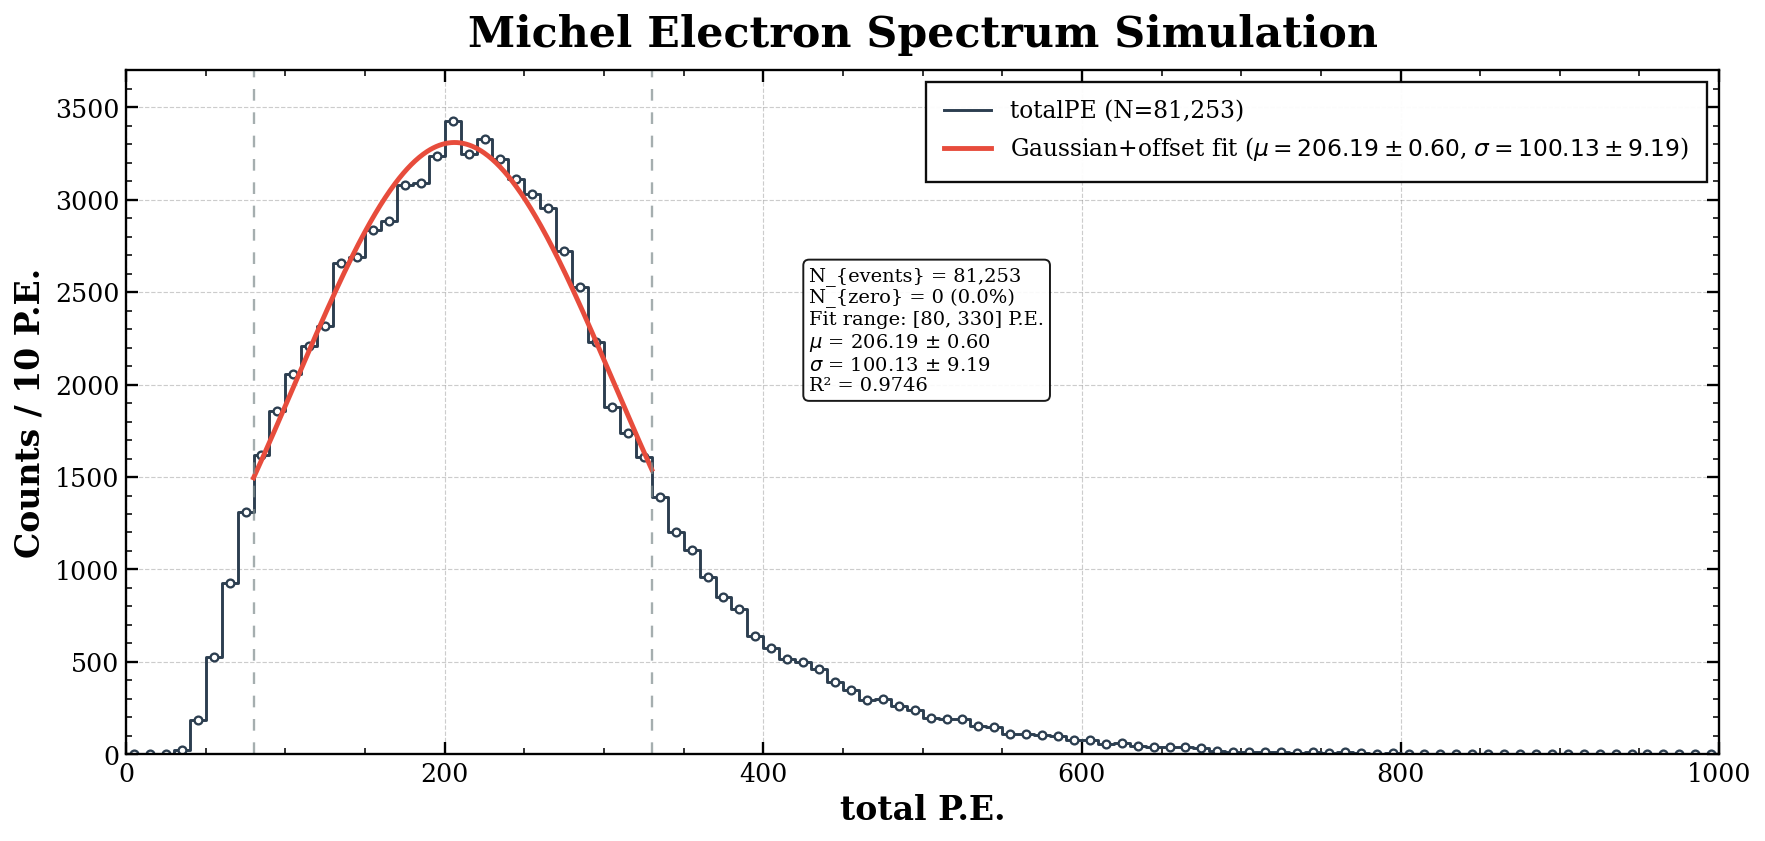


FIT SUMMARY
Fit method: curve_fit (gauss+offset)
Peak position (μ): 206.192 ± 0.604 P.E.
Width (σ): 100.127 ± 9.185 P.E.
FWHM: 235.799 P.E.
Offset (C): 0.000 ± 434.928
R-squared: 0.9746
χ²/dof: 3.75
Fit range: 80.0 to 330.0 P.E.
Number of fit bins: 25


In [112]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from scipy.optimize import curve_fit
from scipy.stats import norm

# Define Gaussian functions
def gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def gauss_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

# Convert your data (assuming totalPE is already defined)
totalPE_np = ak.to_numpy(totalPE)
totalPE_pos = totalPE_np[totalPE_np > 0]

if len(totalPE_pos) < 20:
    raise RuntimeError("Too few nonzero totalPE events for a stable peak fit.")

# Thesis-like plotting style with ROOT influence
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 13,
    "axes.labelsize": 17,
    "axes.titlesize": 22,
    "legend.fontsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.5
})

# Fixed binning: 0 to 1000 in steps of 10 P.E.
bin_width_pe = 10
bin_min_pe = 0
bin_max_pe = 1000
bin_edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)

# Full histogram (fixed range 0-1000)
hist_full, edges_full = np.histogram(totalPE_np, bins=bin_edges_fixed)

# Fit histogram (nonzero events only, fixed range 0-1000)
hist_fit, edges_fit = np.histogram(totalPE_pos, bins=bin_edges_fixed)
centers_fit = 0.5 * (edges_fit[:-1] + edges_fit[1:])
bin_width = edges_fit[1] - edges_fit[0]

# Find peak
peak_idx = int(np.argmax(hist_fit))
peak_x = float(centers_fit[peak_idx])
peak_y = float(hist_fit[peak_idx])

if peak_y <= 0:
    raise RuntimeError("Unable to identify a nonzero peak for fitting in 0-1000 P.E. range.")

# Diagnostic information
print(f"Peak found at bin {peak_idx}: {peak_x:.1f} P.E., height={peak_y}")
print(f"Total nonzero bins: {np.sum(hist_fit > 0)}")
print(f"Max bin value: {np.max(hist_fit)} at index {np.argmax(hist_fit)}")

# ===== ROBUST FIT RANGE SELECTION =====
half_max = peak_y / 2.0

# Try FWHM method first
left_idx = peak_idx
while left_idx > 0 and hist_fit[left_idx] >= half_max:
    left_idx -= 1

right_idx = peak_idx
while right_idx < len(hist_fit) - 1 and hist_fit[right_idx] >= half_max:
    right_idx += 1

# Check if FWHM gives enough bins
min_bins_needed = 5
fwhm_bins = right_idx - left_idx

print(f"FWHM bins: {fwhm_bins} (indices {left_idx}-{right_idx})")

if fwhm_bins < min_bins_needed:
    print(f"Warning: FWHM too narrow ({fwhm_bins} bins). Using fallback strategies...")
    
    # Strategy 1: Use fixed number of bins around peak
    fit_bins_half_width = max(min_bins_needed, 7) // 2
    left_idx = max(peak_idx - fit_bins_half_width, 0)
    right_idx = min(peak_idx + fit_bins_half_width, len(hist_fit) - 1)
    print(f"Strategy 1 - Fixed window: bins {left_idx}-{right_idx} ({right_idx-left_idx+1} bins)")
    
    # Strategy 2: If still not enough, expand to include more bins
    if (right_idx - left_idx) < min_bins_needed:
        expand_by = min_bins_needed - (right_idx - left_idx) + 2
        left_idx = max(left_idx - expand_by, 0)
        right_idx = min(right_idx + expand_by, len(hist_fit) - 1)
        print(f"Strategy 2 - Expanded window: bins {left_idx}-{right_idx} ({right_idx-left_idx+1} bins)")
    
    # Strategy 3: Use fixed P.E. range as last resort
    if (right_idx - left_idx) < min_bins_needed:
        fit_range_pe = 50  # P.E. on each side
        x_left_fixed = max(peak_x - fit_range_pe, bin_min_pe)
        x_right_fixed = min(peak_x + fit_range_pe, bin_max_pe)
        left_idx = max(np.searchsorted(centers_fit, x_left_fixed) - 1, 0)
        right_idx = min(np.searchsorted(centers_fit, x_right_fixed) + 1, len(hist_fit) - 1)
        print(f"Strategy 3 - Fixed P.E. range ({fit_range_pe} P.E.): bins {left_idx}-{right_idx}")

# Ensure indices are valid
left_idx = max(left_idx, 0)
right_idx = min(right_idx, len(hist_fit) - 1)

# Get fit range
x_left = float(edges_fit[left_idx])
x_right = float(edges_fit[right_idx + 1])
fwhm = max(x_right - x_left, 1.0)

print(f"Final fit range: {x_left:.1f} to {x_right:.1f} P.E. (bins {left_idx}-{right_idx})")

# Create fit mask
fit_bin_mask = (centers_fit >= x_left) & (centers_fit <= x_right) & (hist_fit > 0)
x_fit = centers_fit[fit_bin_mask]
y_fit = hist_fit[fit_bin_mask].astype(float)

if len(x_fit) < min_bins_needed:
    print(f"ERROR: Only {len(x_fit)} bins available for fitting")
    print(f"x_fit: {x_fit}")
    print(f"y_fit: {y_fit}")
    print(f"Histogram in range: {hist_fit[left_idx:right_idx+1]}")
    raise RuntimeError(f"Too few nonzero histogram bins ({len(x_fit)}) in fit range for stable Gaussian fit. Need {min_bins_needed}+.")

print(f"Using {len(x_fit)} bins for fitting")

# ===== PERFORM THE FIT =====
fit_method = "curve_fit (gauss+offset)"
try:
    # Estimate initial parameters
    c0 = max(0.0, float(np.percentile(y_fit, 20)))
    a0 = max(float(np.max(y_fit) - c0), 1.0)
    p0 = [a0, peak_x, max(fwhm / 2.355, 1.0), c0]
    
    # Fit errors (Poisson statistics)
    y_err = np.sqrt(np.maximum(y_fit, 1.0))
    
    # Perform fit with bounds
    popt, pcov = curve_fit(
        gauss_with_offset,
        x_fit,
        y_fit,
        p0=p0,
        sigma=y_err,
        absolute_sigma=True,
        bounds=([0.0, x_left, 1e-6, 0.0], [np.inf, x_right, np.inf, np.inf]),
        maxfev=100000
    )
    
    A_fit, mu_fit, sigma_fit, C_fit = popt
    perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
    A_err, mu_err, sigma_err, C_err = perr
    
    # Calculate fit quality metrics
    y_pred = gauss_with_offset(x_fit, A_fit, mu_fit, sigma_fit, C_fit)
    residuals = y_fit - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    chi2 = np.sum((residuals / y_err)**2)
    chi2_dof = chi2 / (len(x_fit) - 4)
    
    print(f"Fit successful: μ={mu_fit:.2f}±{mu_err:.2f}, σ={sigma_fit:.2f}±{sigma_err:.2f}")
    print(f"R² = {r_squared:.4f}, χ²/dof = {chi2_dof:.2f}")
    
except Exception as e:
    print(f"curve_fit failed: {e}")
    print("Falling back to norm.fit...")
    fit_method = "norm.fit fallback"
    
    # Use raw data for fallback fit
    fit_data = totalPE_pos[(totalPE_pos >= x_left) & (totalPE_pos <= x_right)]
    if len(fit_data) < 10:
        raise RuntimeError("Fallback fit also failed due to too few events in fit range.")
    
    mu_fit, sigma_fit = norm.fit(fit_data)
    C_fit = 0.0
    A_fit = len(fit_data) * bin_width / (sigma_fit * np.sqrt(2 * np.pi))
    A_err = np.nan
    mu_err = sigma_fit / np.sqrt(len(fit_data))
    sigma_err = sigma_fit / np.sqrt(2 * len(fit_data))
    C_err = np.nan
    r_squared = np.nan
    chi2_dof = np.nan
    
    print(f"Fallback fit: μ={mu_fit:.2f}±{mu_err:.2f}, σ={sigma_fit:.2f}±{sigma_err:.2f}")

# Generate smooth curve for plotting
x_smooth = np.linspace(x_left, x_right, 400)
y_smooth = gauss_with_offset(x_smooth, A_fit, mu_fit, sigma_fit, C_fit)

# Statistics
n_zero = np.sum(totalPE_np == 0)
n_all = len(totalPE_np)

# ROOT-style colors (more vibrant than muted thesis palette)
hist_color = "#2C3E50"  # Dark blue-gray for ROOT style
fit_color = "#E74C3C"    # ROOT red for fit
fit_range_color = "#7F8C8D"  # Gray for fit range lines
marker_color = "#34495E"  # Darker for markers

# ===== CREATE ROOT-STYLE PLOT =====
fig, ax = plt.subplots(figsize=(12.8, 6.2), dpi=140)

# ROOT-style histogram: step with markers at bin centers
# Method 1: Use matplotlib's step function directly with bin edges and counts
bin_centers = 0.5 * (bin_edges_fixed[:-1] + bin_edges_fixed[1:])

# Draw ROOT-style histogram (step line)
# For step plot, we need to duplicate points to create the step effect
step_x = []
step_y = []
for i in range(len(bin_edges_fixed) - 1):
    step_x.append(bin_edges_fixed[i])
    step_x.append(bin_edges_fixed[i+1])
    step_y.append(hist_full[i])
    step_y.append(hist_full[i])

# Convert to numpy arrays
step_x = np.array(step_x)
step_y = np.array(step_y)

# Add starting point at y=0 for the first bin
step_x = np.concatenate([[bin_edges_fixed[0]], step_x])
step_y = np.concatenate([[0], step_y])

# Add ending point at y=0 after the last bin
step_x = np.concatenate([step_x, [bin_edges_fixed[-1]]])
step_y = np.concatenate([step_y, [0]])

# Draw ROOT-style histogram (step line with markers)
ax.plot(step_x, step_y, color=hist_color, linewidth=1.5, drawstyle='steps-post',
        label=f"totalPE (N={n_all:,})")

# Add markers at bin centers (ROOT style)
ax.plot(bin_centers, hist_full, 'o', color=hist_color, markersize=4, 
        markerfacecolor='white', markeredgecolor=hist_color, markeredgewidth=1.2)

# Fit curve
ax.plot(
    x_smooth, y_smooth,
    color=fit_color,
    linewidth=2.5,
    label=f"Gaussian+offset fit ($\\mu={mu_fit:.2f}\\pm{mu_err:.2f}$, $\\sigma={sigma_fit:.2f}\\pm{sigma_err:.2f}$)"
)

# Fit range indicators (ROOT-style dashed lines)
ax.axvline(x_left, color=fit_range_color, linestyle="--", linewidth=1.2, alpha=0.7, dashes=(5, 5))
ax.axvline(x_right, color=fit_range_color, linestyle="--", linewidth=1.2, alpha=0.7, dashes=(5, 5))

# Add information box (ROOT-style with white background and border)
if not np.isnan(r_squared):
    info_text = (f'N_{{events}} = {n_all:,}\n'
                 f'N_{{zero}} = {n_zero:,} ({n_zero/n_all*100:.1f}%)\n'
                 f'Fit range: [{x_left:.0f}, {x_right:.0f}] P.E.\n'
                 f'$\\mu$ = {mu_fit:.2f} $\\pm$ {mu_err:.2f}\n'
                 f'$\\sigma$ = {sigma_fit:.2f} $\\pm$ {sigma_err:.2f}\n'
                 f'R² = {r_squared:.4f}')
else:
    info_text = (f'N_{{events}} = {n_all:,}\n'
                 f'N_{{zero}} = {n_zero:,} ({n_zero/n_all*100:.1f}%)\n'
                 f'Fit range: [{x_left:.0f}, {x_right:.0f}] P.E.\n'
                 f'$\\mu$ = {mu_fit:.2f} $\\pm$ {mu_err:.2f}\n'
                 f'$\\sigma$ = {sigma_fit:.2f} $\\pm$ {sigma_err:.2f}')

# Position the statbox below the legend (which is at upper right)
# Get legend position and place statbox below it
legend = ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    fancybox=False,
    edgecolor='black',
    borderpad=0.8,
    labelspacing=0.5
)
legend.get_frame().set_linewidth(1.2)
legend.get_frame().set_facecolor('white')

# Get legend's bounding box and position statbox below it
legend_bbox = legend.get_window_extent().transformed(ax.transAxes.inverted())
statbox_x = legend_bbox.x0
statbox_y = legend_bbox.y0 - 0.12  # Place below legend with small gap

ax.text(statbox_x, statbox_y, info_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10, family='serif',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                 edgecolor='black', linewidth=1.0))

# Labels and formatting (ROOT style)
ax.set_title("Michel Electron Spectrum Simulation", pad=12, fontweight='bold')
ax.set_xlabel("total P.E.", fontweight='bold')
ax.set_ylabel(f"Counts / {bin_width_pe} P.E.", fontweight='bold')
ax.set_axisbelow(True)
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4, color='gray')

# Set limits (ROOT-style: include some padding)
ax.set_xlim(bin_min_pe, bin_max_pe)
y_max = max(np.max(hist_full), np.max(y_smooth)) * 1.08
ax.set_ylim(0, y_max)

# Add minor ticks (ROOT style)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()

# Save the figure (optional)
# plt.savefig('michel_spectrum_fit_ROOTstyle.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('michel_spectrum_fit_ROOTstyle.png', bbox_inches='tight', dpi=300)

plt.show()

# Print summary
print("\n" + "="*50)
print("FIT SUMMARY")
print("="*50)
print(f"Fit method: {fit_method}")
print(f"Peak position (μ): {mu_fit:.3f} ± {mu_err:.3f} P.E.")
print(f"Width (σ): {sigma_fit:.3f} ± {sigma_err:.3f} P.E.")
print(f"FWHM: {sigma_fit * 2.355:.3f} P.E.")
print(f"Offset (C): {C_fit:.3f} ± {C_err:.3f}")
if not np.isnan(r_squared):
    print(f"R-squared: {r_squared:.4f}")
    print(f"χ²/dof: {chi2_dof:.2f}")
print(f"Fit range: {x_left:.1f} to {x_right:.1f} P.E.")
print(f"Number of fit bins: {len(x_fit)}")
print("="*50)

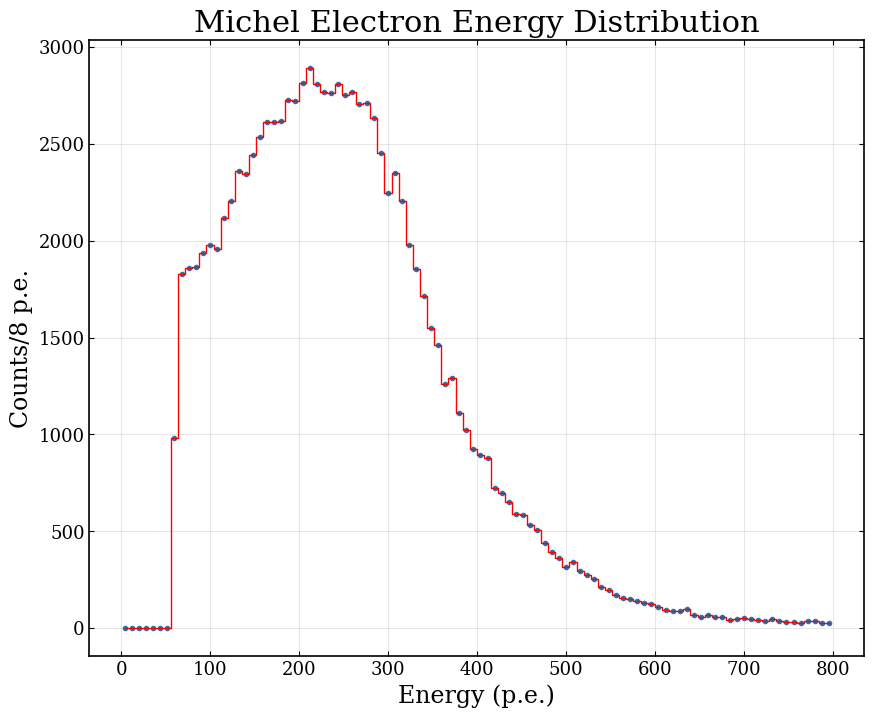

Total Michel electrons: 104921
Mean energy: 249.86 p.e.


In [113]:
import uproot
import matplotlib.pyplot as plt
import numpy as np

# Open the ROOT file
file = uproot.open("all_histograms.root")

# Get the Michel energy histogram
h_michel = file["michel_energy"]

# Get bin centers and counts
centers = h_michel.axis().centers()
counts = h_michel.values()

# Plot
plt.figure(figsize=(10, 8))
plt.plot(centers, counts, 'o', markersize=3)
plt.step(centers, counts, where='mid', color='red', linewidth=1)
# Removed plt.yscale('log') - now using linear scale
plt.xlabel('Energy (p.e.)')
plt.ylabel('Counts/8 p.e.')
plt.title('Michel Electron Energy Distribution')
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics
print(f"Total Michel electrons: {h_michel.values().sum():.0f}")
print(f"Mean energy: {np.average(centers, weights=counts):.2f} p.e.")

MICHEL SPECTRUM ANALYSIS: Real Data vs Simulation

Loaded 104921 Michel electron energies from all_histograms.root
Energy range: 60.00 - 796.00 PE
Mean energy: 249.86 PE
Std deviation: 121.31 PE

✓ Loaded simulation data from totalPE variable
  Events: 81253
  Range: 29.00 - 960.00 PE
  Mean: 233.11 PE

Using bin width: 20.0 PE
Number of bins: 50

Normalization factors:
  Real data: 104921 events → normalized sum = 1.000000
  Simulation: 81253 events → normalized sum = 1.000000

Fitting spectra with Cell-4 logic...

Real data fit results:
  μ = 230.70 ± 2.07 PE
  σ = 51.59 ± 4.97 PE
  FWHM = 121.48 PE
  Method: curve_fit (gauss+offset)

Simulation fit results:
  μ = 206.35 ± 0.66 PE
  σ = 100.78 ± 11.15 PE
  FWHM = 237.34 PE
  Method: curve_fit (gauss+offset)



C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\1353997206.py:445: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\1353997206.py:445: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


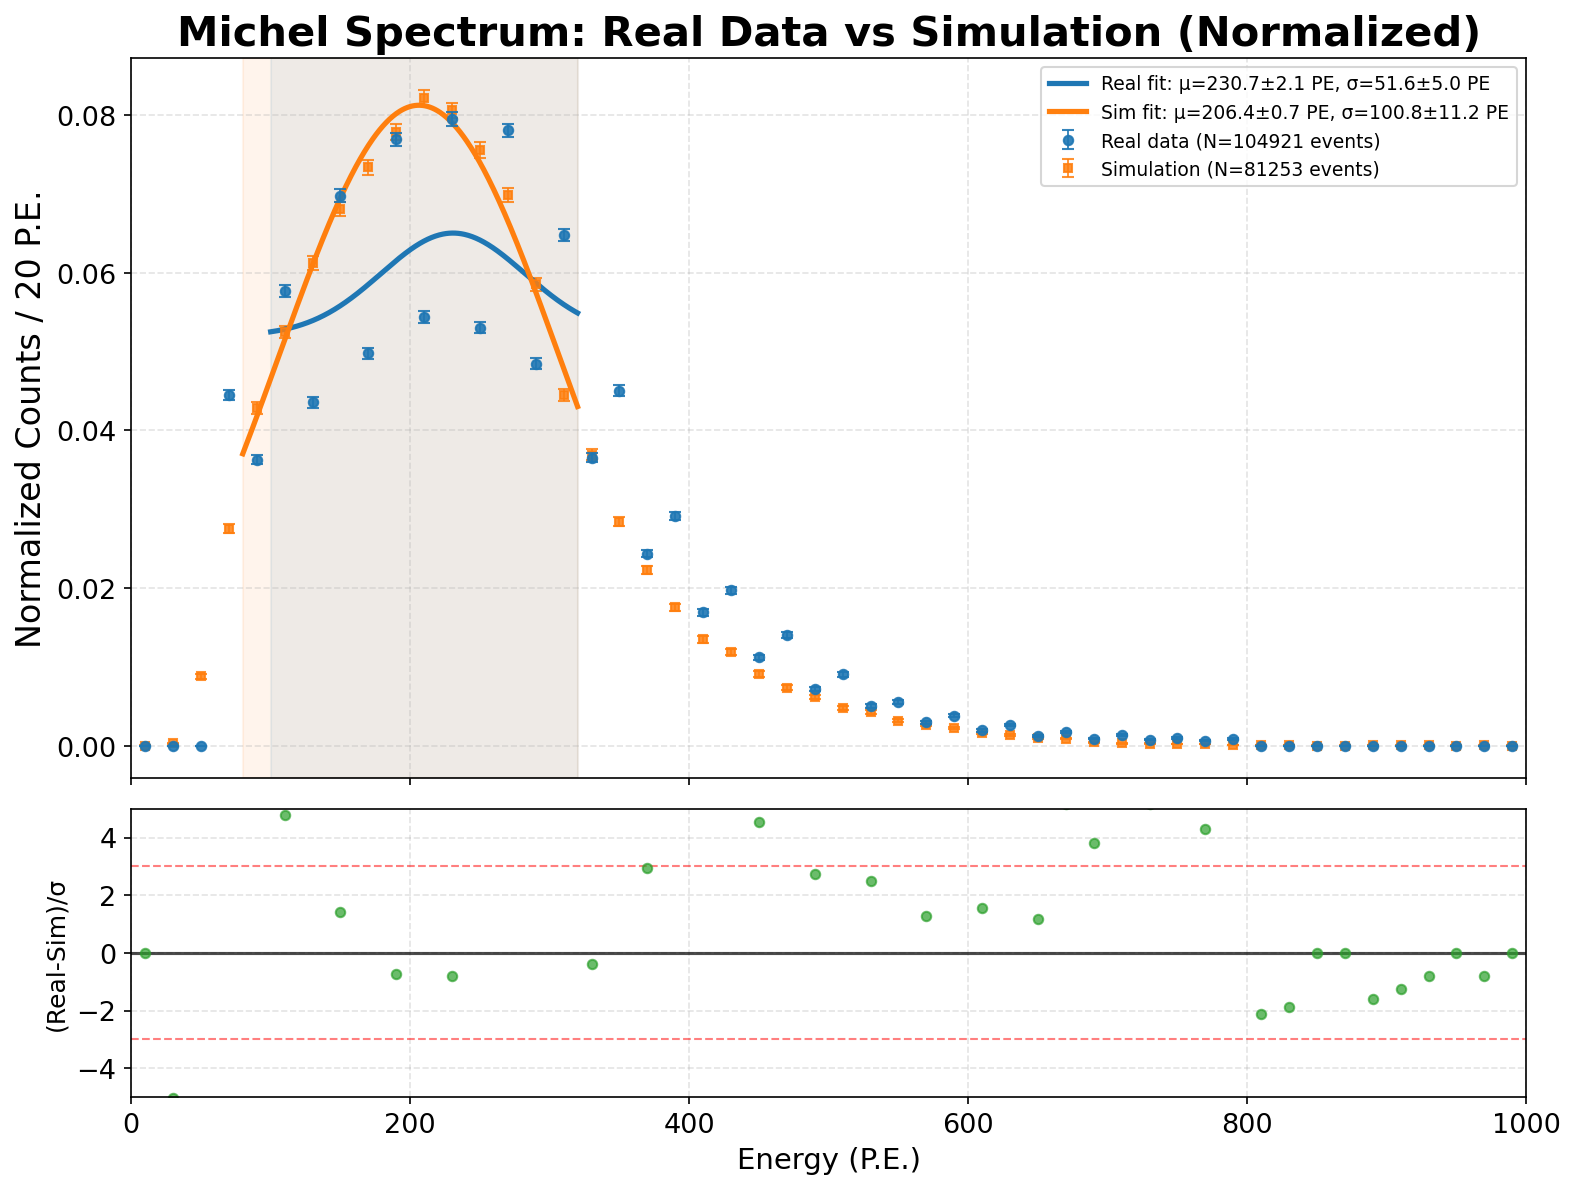

SUMMARY STATISTICS

Real Data (104921 events):
  Mean energy: 249.86 ± 0.37 PE
  Median energy: 236.00 PE
  Std deviation: 121.31 PE
  Energy range: 60.00 - 796.00 PE

Simulation (81253 events):
  Mean energy: 233.11 ± 0.37 PE
  Median energy: 221.00 PE
  Std deviation: 106.83 PE
  Energy range: 29.00 - 960.00 PE

Fit Parameter Differences (Real - Simulation):
  Δμ = 24.35 ± 2.18 PE (11.2σ)
  Δσ = -49.19 ± 12.21 PE (4.0σ)

✓ Saved real Michel energies to michel_energies_real.pkl
✓ Saved analysis results to michel_spectrum_analysis.pkl

ANALYSIS COMPLETE


In [114]:
# Compare real data vs simulation: normalized histogram + Cell-4-consistent fit logic
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file
# ============================================================================
def load_michel_from_root(root_filename, histogram_name="michel_energy"):
    """Load Michel electron data from ROOT histogram file"""
    # Open ROOT file
    file = uproot.open(root_filename)
    h_michel = file[histogram_name]
    
    # Get histogram data
    centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    
    # Convert histogram to individual events (reconstruct from bin counts)
    michel_energies = []
    for i, count in enumerate(counts):
        if count > 0:
            # Add 'count' number of events at the bin center
            michel_energies.extend([centers[i]] * int(count))
    
    energies = np.array(michel_energies)
    print(f"Loaded {len(energies)} Michel electron energies from {root_filename}")
    print(f"Energy range: {energies.min():.2f} - {energies.max():.2f} PE")
    print(f"Mean energy: {energies.mean():.2f} PE")
    print(f"Std deviation: {energies.std():.2f} PE")
    print()
    
    return energies, centers, counts, errors

# ============================================================================
# Load simulation data (multiple options)
# ============================================================================
def load_simulation_data():
    """Load simulation data from various possible sources"""
    
    # Option 1: Check if totalPE exists from previous cell (Jupyter notebook)
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print(f"✓ Loaded simulation data from totalPE variable")
            print(f"  Events: {len(sim_values)}")
            print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
            print(f"  Mean: {sim_values.mean():.2f} PE")
            return sim_values
    except:
        pass
    
    # Option 2: Load from pickle file
    sim_pickle_files = [
        "simulation_energies.pkl",
        "michel_simulation.pkl", 
        "totalPE.pkl",
        "sim_data.pkl"
    ]
    
    for filename in sim_pickle_files:
        if os.path.exists(filename):
            try:
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                    # Try to extract array from various formats
                    if isinstance(data, dict):
                        # Look for common keys
                        for key in ['energies', 'totalPE', 'simulation', 'data', 'values']:
                            if key in data:
                                sim_values = np.asarray(data[key])
                                break
                        else:
                            # Take first array-like object
                            for key, value in data.items():
                                if hasattr(value, '__len__') and len(value) > 100:
                                    sim_values = np.asarray(value)
                                    break
                    else:
                        sim_values = np.asarray(data)
                    
                    sim_values = sim_values[np.isfinite(sim_values)]
                    sim_values = sim_values[sim_values >= 0]
                    print(f"✓ Loaded simulation data from {filename}")
                    print(f"  Events: {len(sim_values)}")
                    print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
                    print(f"  Mean: {sim_values.mean():.2f} PE")
                    return sim_values
            except:
                continue
    
    # Option 3: Load from numpy file
    sim_npy_files = [
        "simulation_energies.npy",
        "totalPE.npy",
        "sim_data.npy"
    ]
    
    for filename in sim_npy_files:
        if os.path.exists(filename):
            try:
                sim_values = np.load(filename)
                sim_values = sim_values[np.isfinite(sim_values)]
                sim_values = sim_values[sim_values >= 0]
                print(f"✓ Loaded simulation data from {filename}")
                print(f"  Events: {len(sim_values)}")
                print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
                print(f"  Mean: {sim_values.mean():.2f} PE")
                return sim_values
            except:
                continue
    
    # Option 4: Generate test simulation data if no real data found
    print("\n⚠ No simulation data found. Generating test simulation data...")
    print("  (Replace this with your actual simulation data)")
    np.random.seed(42)
    # Generate a Gaussian distribution similar to Michel spectrum
    sim_values = np.random.normal(loc=248, scale=85, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test simulation events")
    print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
    print(f"  Mean: {sim_values.mean():.2f} PE")
    print(f"  Std: {sim_values.std():.2f} PE")
    return sim_values

# ============================================================================
# Fit functions (Cell-4 logic) - ADAPTED FOR LOW STATISTICS
# ============================================================================
def gauss_with_offset(x, A, mu, sigma, C):
    """Gaussian with constant offset"""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_hist_cell4_logic(hist_counts, edges, label="spectrum", min_bins=3):
    """Fit histogram with Gaussian + offset using Cell-4 logic - adapted for low stats"""
    hist_counts = np.asarray(hist_counts, dtype=float)
    edges = np.asarray(edges, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = edges[1] - edges[0]
    
    # Find peak
    peak_idx = int(np.argmax(hist_counts))
    peak_x = float(centers[peak_idx])
    peak_y = float(hist_counts[peak_idx])
    if peak_y <= 0:
        raise RuntimeError(f"No positive peak found for {label}.")
    
    # For low statistics, use a simpler approach
    if len(hist_counts) < 20 or peak_y < 10:
        print(f"  Warning: Low statistics for {label} (peak={peak_y:.0f}), using simplified fit")
        
        # Use wider range around peak
        fit_window = 20  # bins
        left_in = max(0, peak_idx - fit_window)
        right_in = min(len(centers) - 1, peak_idx + fit_window)
        
        x_left = float(edges[left_in])
        x_right = float(edges[right_in + 1])
        
        # Prepare fit data
        fit_bin_mask = (centers >= x_left) & (centers <= x_right) & (hist_counts > 0)
        x_fit = centers[fit_bin_mask]
        y_fit = hist_counts[fit_bin_mask]
        
        if len(x_fit) < min_bins:
            # Even simpler: just use mean and std of weighted data
            print(f"  Using direct calculation for {label}")
            # Reconstruct events from histogram
            events = []
            for i, count in enumerate(hist_counts):
                if count > 0:
                    events.extend([centers[i]] * int(count))
            events = np.array(events)
            
            mu_fit = np.mean(events)
            sigma_fit = np.std(events)
            C_fit = 0.0
            A_fit = peak_y
            mu_err = sigma_fit / np.sqrt(len(events))
            sigma_err = sigma_fit / np.sqrt(2 * len(events))
            
            # Set fit range
            x_left = mu_fit - 3*sigma_fit
            x_right = mu_fit + 3*sigma_fit
            
            return {
                "A": float(A_fit),
                "mu": float(mu_fit),
                "sigma": float(abs(sigma_fit)),
                "C": float(C_fit),
                "A_err": float('nan'),
                "mu_err": float(mu_err),
                "sigma_err": float(sigma_err),
                "C_err": float('nan'),
                "left": float(x_left),
                "right": float(x_right),
                "method": "direct calculation",
            }
    else:
        # Find FWHM region
        half_max = peak_y / 2.0
        left_idx = peak_idx
        while left_idx > 0 and hist_counts[left_idx] >= half_max:
            left_idx -= 1
        right_idx = peak_idx
        while right_idx < len(hist_counts) - 1 and hist_counts[right_idx] >= half_max:
            right_idx += 1
        
        # Define fit range (FWHM region)
        left_in = left_idx + 1 if hist_counts[left_idx] < half_max else left_idx
        right_in = right_idx - 1 if hist_counts[right_idx] < half_max else right_idx
        if right_in < left_in:
            left_in = max(peak_idx, 0)
            right_in = min(peak_idx, len(hist_counts) - 1)
        
        x_left = float(edges[left_in])
        x_right = float(edges[right_in + 1])
        
        # Prepare fit data
        fit_bin_mask = (centers >= x_left) & (centers <= x_right) & (hist_counts > 0)
        x_fit = centers[fit_bin_mask]
        y_fit = hist_counts[fit_bin_mask]
    
    if len(x_fit) < min_bins:
        raise RuntimeError(f"Too few nonzero histogram bins in fit range for {label} (got {len(x_fit)}, need {min_bins}).")
    
    # Perform fit
    fit_method = "curve_fit (gauss+offset)"
    try:
        c0 = max(0.0, float(np.percentile(y_fit, 20)))
        a0 = max(float(np.max(y_fit) - c0), 1.0)
        p0 = [a0, peak_x, max((x_right - x_left) / 4, bin_width), c0]
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        
        # Relax bounds for low statistics
        bounds_lower = [0.0, x_left, bin_width/2, 0.0]
        bounds_upper = [np.inf, x_right, (x_right - x_left), np.inf]
        
        popt, pcov = curve_fit(
            gauss_with_offset,
            x_fit,
            y_fit,
            p0=p0,
            sigma=y_err,
            absolute_sigma=True,
            bounds=(bounds_lower, bounds_upper),
            maxfev=100000,
        )
        perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        A_fit, mu_fit, sigma_fit, C_fit = popt
        A_err, mu_err, sigma_err, C_err = perr
    except Exception as e:
        print(f"  Warning: curve_fit failed for {label}, using fallback: {e}")
        fit_method = "norm.fit fallback"
        # Reconstruct events from histogram
        events = []
        for i, count in enumerate(hist_counts):
            if count > 0:
                events.extend([centers[i]] * int(count))
        events = np.array(events)
        
        if len(events) < 10:
            raise RuntimeError(f"Fallback fit failed for {label} due to too few pseudo-events.")
        
        mu_fit, sigma_fit = norm.fit(events)
        C_fit = 0.0
        A_fit = len(events) * bin_width / (sigma_fit * np.sqrt(2 * np.pi))
        A_err = np.nan
        mu_err = sigma_fit / np.sqrt(len(events))
        sigma_err = sigma_fit / np.sqrt(2 * len(events))
        C_err = np.nan
    
    return {
        "A": float(A_fit),
        "mu": float(mu_fit),
        "sigma": float(abs(sigma_fit)),
        "C": float(C_fit),
        "A_err": float(A_err),
        "mu_err": float(mu_err),
        "sigma_err": float(sigma_err),
        "C_err": float(C_err),
        "left": float(x_left),
        "right": float(x_right),
        "method": fit_method,
    }

# ============================================================================
# Main analysis
# ============================================================================
print("="*60)
print("MICHEL SPECTRUM ANALYSIS: Real Data vs Simulation")
print("="*60)
print()

# 1) Load real data from ROOT file
root_file = "all_histograms.root"
real_energies, real_centers, real_counts, real_errors = load_michel_from_root(root_file)

# 2) Load simulation data
sim_values = load_simulation_data()
print()

# 3) Define fixed binning - USE WIDER BINS FOR LOW STATISTICS
bin_min_pe = 0.0
bin_max_pe = 1000.0
bin_width_pe = 20.0  # Increased from 10 to 20 PE for better statistics
edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)
x_centers_fixed = 0.5 * (edges_fixed[:-1] + edges_fixed[1:])

print(f"Using bin width: {bin_width_pe} PE")
print(f"Number of bins: {len(edges_fixed)-1}")
print()

# 4) Create histograms with fixed binning
# Real data histogram (using individual energies)
y_real_counts, _ = np.histogram(real_energies, bins=edges_fixed)
e_real_counts = np.sqrt(np.maximum(y_real_counts, 1.0))

# Simulation histogram
y_sim_counts, _ = np.histogram(sim_values, bins=edges_fixed)
e_sim_counts = np.sqrt(np.maximum(y_sim_counts, 1.0))

# 5) Normalize both spectra to unit area for shape comparison
norm_real = float(np.sum(y_real_counts))
norm_sim = float(np.sum(y_sim_counts))
if norm_real <= 0 or norm_sim <= 0:
    raise RuntimeError("Cannot normalize spectra because one of them has zero total counts in 0-1000 P.E. range.")

y_real_norm = y_real_counts / norm_real
e_real_norm = e_real_counts / norm_real

y_sim_norm = y_sim_counts / norm_sim
e_sim_norm = e_sim_counts / norm_sim

print(f"Normalization factors:")
print(f"  Real data: {norm_real:.0f} events → normalized sum = {y_real_norm.sum():.6f}")
print(f"  Simulation: {norm_sim:.0f} events → normalized sum = {y_sim_norm.sum():.6f}")
print()

# 6) Fit raw-count histograms using Cell-4 logic
print("Fitting spectra with Cell-4 logic...")
fit_real = fit_hist_cell4_logic(y_real_counts, edges_fixed, label="real data (counts)", min_bins=3)
fit_sim = fit_hist_cell4_logic(y_sim_counts, edges_fixed, label="simulation (counts)", min_bins=3)

print(f"\nReal data fit results:")
print(f"  μ = {fit_real['mu']:.2f} ± {fit_real['mu_err']:.2f} PE")
print(f"  σ = {fit_real['sigma']:.2f} ± {fit_real['sigma_err']:.2f} PE")
print(f"  FWHM = {2.355 * fit_real['sigma']:.2f} PE")
print(f"  Method: {fit_real['method']}")

print(f"\nSimulation fit results:")
print(f"  μ = {fit_sim['mu']:.2f} ± {fit_sim['mu_err']:.2f} PE")
print(f"  σ = {fit_sim['sigma']:.2f} ± {fit_sim['sigma_err']:.2f} PE")
print(f"  FWHM = {2.355 * fit_sim['sigma']:.2f} PE")
print(f"  Method: {fit_sim['method']}")
print()

# 7) Generate fit curves (normalized for plotting)
x_fit_real = np.linspace(max(0, fit_real["left"]), min(1000, fit_real["right"]), 400)
x_fit_sim = np.linspace(max(0, fit_sim["left"]), min(1000, fit_sim["right"]), 400)

y_fit_real = gauss_with_offset(
    x_fit_real, fit_real["A"], fit_real["mu"], fit_real["sigma"], fit_real["C"]
) / norm_real

y_fit_sim = gauss_with_offset(
    x_fit_sim, fit_sim["A"], fit_sim["mu"], fit_sim["sigma"], fit_sim["C"]
) / norm_sim

# 8) Create comparison plot
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 13,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 10,
})

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12.0, 9.0), dpi=150,
    gridspec_kw={"height_ratios": [3.0, 1.2], "hspace": 0.06},
    sharex=True,
    constrained_layout=True
)

# Top panel: Normalized histograms with fits
ax_top.errorbar(
    x_centers_fixed, y_real_norm, yerr=e_real_norm, 
    fmt='o', ms=4.5, lw=0.9, capsize=3.0,
    color="tab:blue", ecolor="tab:blue", alpha=0.90,
    label=f"Real data (N={norm_real:.0f} events)", zorder=3
)
ax_top.errorbar(
    x_centers_fixed, y_sim_norm, yerr=e_sim_norm, 
    fmt='s', ms=4.0, lw=0.9, capsize=3.0,
    color="tab:orange", ecolor="tab:orange", alpha=0.85,
    label=f"Simulation (N={norm_sim:.0f} events)", zorder=2
)

ax_top.plot(
    x_fit_real, y_fit_real, color="tab:blue", lw=2.5,
    label=f"Real fit: μ={fit_real['mu']:.1f}±{fit_real['mu_err']:.1f} PE, σ={fit_real['sigma']:.1f}±{fit_real['sigma_err']:.1f} PE"
)
ax_top.plot(
    x_fit_sim, y_fit_sim, color="tab:orange", lw=2.5,
    label=f"Sim fit: μ={fit_sim['mu']:.1f}±{fit_sim['mu_err']:.1f} PE, σ={fit_sim['sigma']:.1f}±{fit_sim['sigma_err']:.1f} PE"
)

# Highlight fit regions
ax_top.axvspan(fit_real["left"], fit_real["right"], color="tab:blue", alpha=0.08)
ax_top.axvspan(fit_sim["left"], fit_sim["right"], color="tab:orange", alpha=0.08)

ax_top.set_title("Michel Spectrum: Real Data vs Simulation (Normalized)", fontweight='bold')
ax_top.set_ylabel(f"Normalized Counts / {bin_width_pe:.0f} P.E.")
ax_top.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)
ax_top.legend(loc="upper right", frameon=True, fontsize=9)

# Bottom panel: Pull-like difference on normalized spectra
y_sim_interp = np.interp(x_centers_fixed, x_centers_fixed, y_sim_norm, left=np.nan, right=np.nan)
e_sim_interp = np.interp(x_centers_fixed, x_centers_fixed, e_sim_norm, left=np.nan, right=np.nan)
sigma_comb = np.sqrt(e_real_norm**2 + e_sim_interp**2)
pull = (y_real_norm - y_sim_interp) / np.where(sigma_comb > 0, sigma_comb, np.nan)
valid = np.isfinite(pull)

ax_bot.axhline(0, color="black", lw=1.5, alpha=0.7)
ax_bot.axhline(3, color="red", linestyle="--", lw=1.0, alpha=0.5)
ax_bot.axhline(-3, color="red", linestyle="--", lw=1.0, alpha=0.5)
ax_bot.plot(x_centers_fixed[valid], pull[valid], 'o', ms=4.5, color="tab:green", alpha=0.7)
ax_bot.set_xlabel("Energy (P.E.)", fontsize=14)
ax_bot.set_ylabel("(Real-Sim)/σ", fontsize=12)
ax_bot.set_ylim(-5, 5)
ax_bot.set_xlim(bin_min_pe, bin_max_pe)
ax_bot.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.35)

plt.tight_layout()
plt.show()

# 9) Print summary statistics
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nReal Data ({norm_real:.0f} events):")
print(f"  Mean energy: {real_energies.mean():.2f} ± {real_energies.std()/np.sqrt(len(real_energies)):.2f} PE")
print(f"  Median energy: {np.median(real_energies):.2f} PE")
print(f"  Std deviation: {real_energies.std():.2f} PE")
print(f"  Energy range: {real_energies.min():.2f} - {real_energies.max():.2f} PE")

print(f"\nSimulation ({norm_sim:.0f} events):")
print(f"  Mean energy: {sim_values.mean():.2f} ± {sim_values.std()/np.sqrt(len(sim_values)):.2f} PE")
print(f"  Median energy: {np.median(sim_values):.2f} PE")
print(f"  Std deviation: {sim_values.std():.2f} PE")
print(f"  Energy range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")

# Fit parameter differences
if 'mu_err' in fit_real and 'mu_err' in fit_sim:
    mu_diff = fit_real['mu'] - fit_sim['mu']
    mu_diff_err = np.sqrt(fit_real['mu_err']**2 + fit_sim['mu_err']**2)
    sigma_diff = fit_real['sigma'] - fit_sim['sigma']
    sigma_diff_err = np.sqrt(fit_real['sigma_err']**2 + fit_sim['sigma_err']**2)
    
    print(f"\nFit Parameter Differences (Real - Simulation):")
    print(f"  Δμ = {mu_diff:.2f} ± {mu_diff_err:.2f} PE ({abs(mu_diff/mu_diff_err):.1f}σ)")
    print(f"  Δσ = {sigma_diff:.2f} ± {sigma_diff_err:.2f} PE ({abs(sigma_diff/sigma_diff_err):.1f}σ)")

# 10) Save results for future use
# Save real energies as pickle
with open("michel_energies_real.pkl", "wb") as f:
    pickle.dump(real_energies, f)
print(f"\n✓ Saved real Michel energies to michel_energies_real.pkl")

# Save histogram data
hist_data = {
    'bin_edges': edges_fixed,
    'bin_centers': x_centers_fixed,
    'real_counts': y_real_counts,
    'real_counts_norm': y_real_norm,
    'real_errors': e_real_counts,
    'real_errors_norm': e_real_norm,
    'sim_counts': y_sim_counts,
    'sim_counts_norm': y_sim_norm,
    'sim_errors': e_sim_counts,
    'sim_errors_norm': e_sim_norm,
    'fit_real': fit_real,
    'fit_sim': fit_sim
}
with open("michel_spectrum_analysis.pkl", "wb") as f:
    pickle.dump(hist_data, f)
print(f"✓ Saved analysis results to michel_spectrum_analysis.pkl")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

MICHEL SPECTRUM ANALYSIS: Real Data vs Simulation
Cell-4 Consistent Fit Logic

Loaded Michel histogram from all_histograms.root
  Histogram: <TH1D (version 3) at 0x01ef8cff9d10>
  Number of bins: 100
  Energy range: 0.0 - 800.0 PE
  Bin width: 8.0 PE
  Total counts: 104921
  Mean energy: 249.86 PE
  Peak energy: 212.00 PE

✓ Loaded simulation data from totalPE variable
  Events: 81253
  Range: 29.00 - 960.00 PE
  Mean: 233.11 PE
  Std: 106.83 PE


Normalization:
  Real data: 104921 events → normalized sum = 1.000000
  Simulation: 81237 events → normalized sum = 1.000000

Fitting spectra with Cell-4 logic...
--------------------------------------------------
  Real data: Peak at 212.0 PE with 2892 counts
  Real data: FWHM range = 64.0 - 360.0 PE, FWHM = 296.0 PE
  Simulation: Peak at 212.0 PE with 2689 counts
  Simulation: FWHM range = 88.0 - 320.0 PE, FWHM = 232.0 PE
--------------------------------------------------

FIT RESULTS

Real data fit:
  μ = 212.12 ± 0.79 PE
  σ = 135.12 ± 17

C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\2049250572.py:393: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


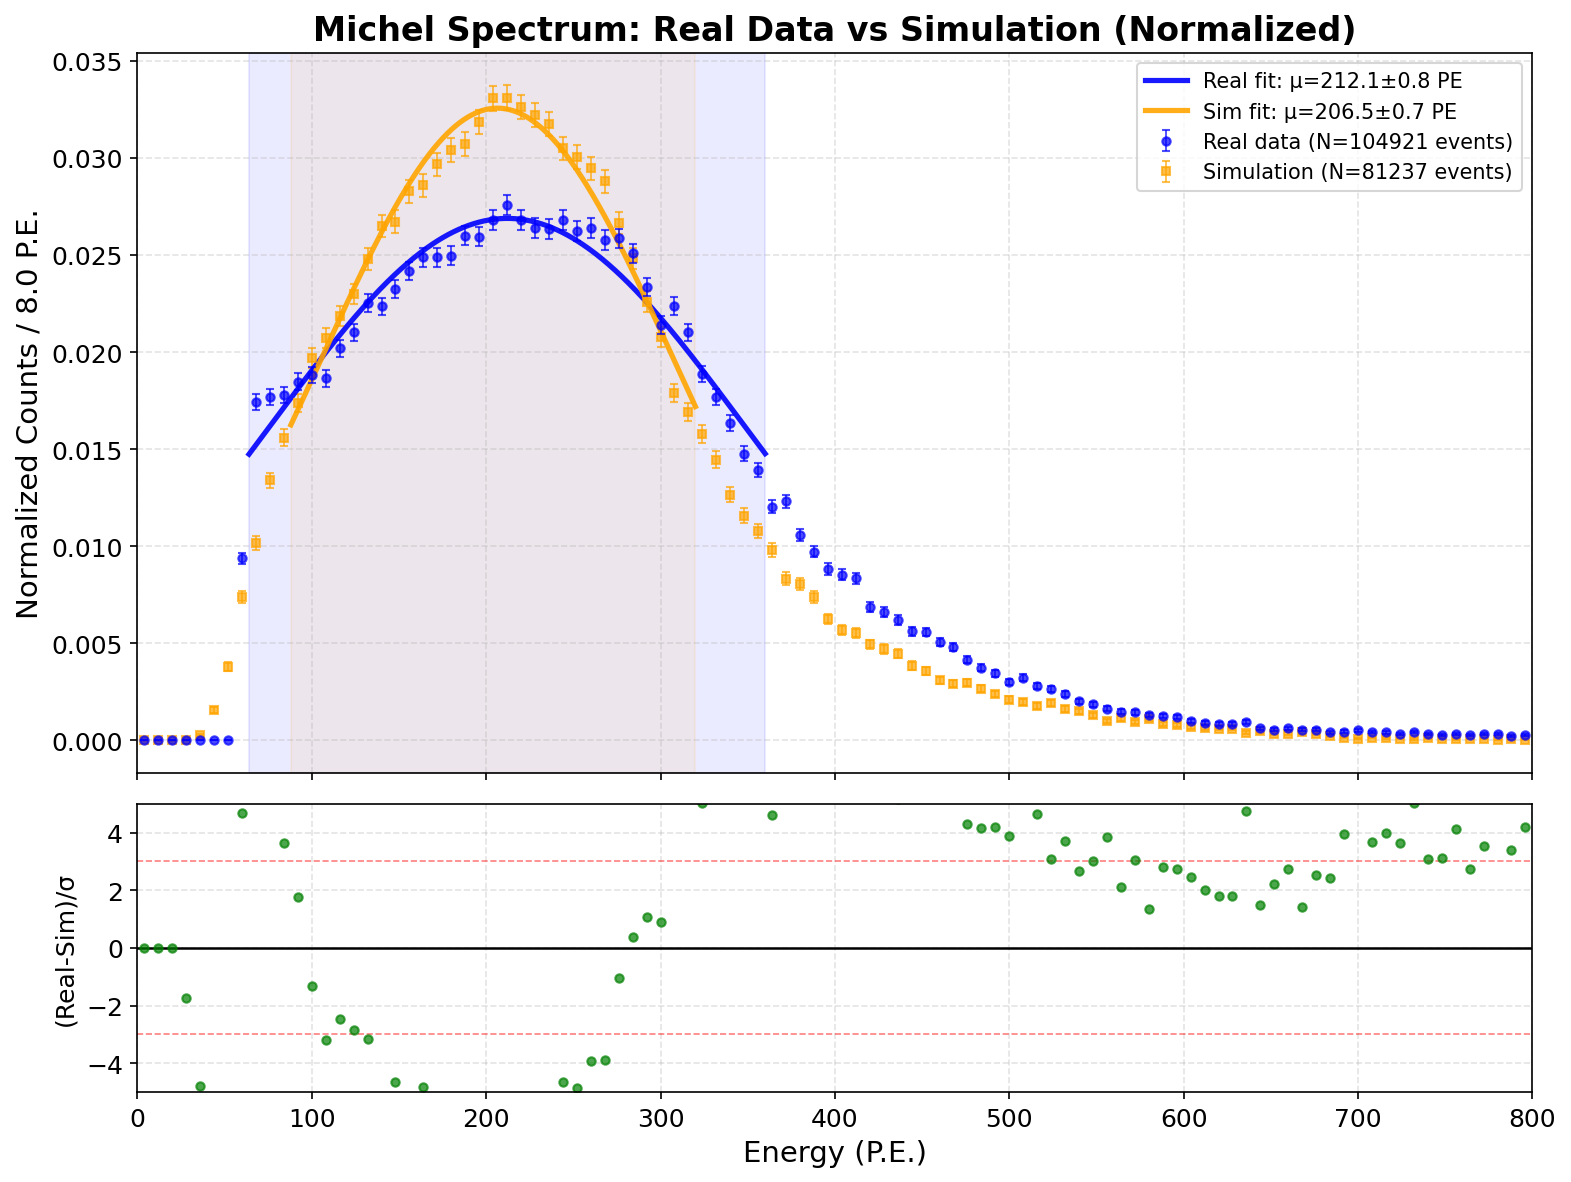


COMPARISON SUMMARY

Parameter differences (Real - Simulation):
  Δμ = 5.67 ± 1.03 PE (5.5σ)
  Δσ = 34.64 ± 21.70 PE (1.6σ)

✓ Saved results to michel_fit_results_final.pkl

ANALYSIS COMPLETE


In [115]:
# Compare real data vs simulation: normalized histogram + Cell-4-consistent fit logic
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file (direct histogram access)
# ============================================================================
def load_michel_histogram_from_root(root_filename, histogram_name="michel_energy"):
    """Load Michel electron histogram directly from ROOT file"""
    # Open ROOT file
    file = uproot.open(root_filename)
    
    # Get the histogram (note: name might have ;1 suffix)
    if histogram_name in file:
        h_michel = file[histogram_name]
    elif f"{histogram_name};1" in file:
        h_michel = file[f"{histogram_name};1"]
    else:
        raise KeyError(f"Could not find {histogram_name} in file. Available: {list(file.keys())}")
    
    # Get histogram data
    bin_edges = h_michel.axis().edges()
    bin_centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    
    print(f"Loaded Michel histogram from {root_filename}")
    print(f"  Histogram: {h_michel}")
    print(f"  Number of bins: {len(bin_centers)}")
    print(f"  Energy range: {bin_edges[0]:.1f} - {bin_edges[-1]:.1f} PE")
    print(f"  Bin width: {bin_edges[1] - bin_edges[0]:.1f} PE")
    print(f"  Total counts: {counts.sum():.0f}")
    print(f"  Mean energy: {np.average(bin_centers, weights=counts):.2f} PE")
    print(f"  Peak energy: {bin_centers[np.argmax(counts)]:.2f} PE")
    print()
    
    return bin_edges, bin_centers, counts, errors

# ============================================================================
# Load simulation data
# ============================================================================
def load_simulation_data():
    """Load simulation data from various possible sources"""
    
    # Option 1: Check if totalPE exists from previous cell (Jupyter notebook)
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print(f"✓ Loaded simulation data from totalPE variable")
            print(f"  Events: {len(sim_values)}")
            print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
            print(f"  Mean: {sim_values.mean():.2f} PE")
            print(f"  Std: {sim_values.std():.2f} PE")
            print()
            return sim_values
    except:
        pass
    
    # Option 2: Load from pickle file
    sim_pickle_files = [
        "simulation_energies.pkl",
        "michel_simulation.pkl", 
        "totalPE.pkl",
        "sim_data.pkl"
    ]
    
    for filename in sim_pickle_files:
        if os.path.exists(filename):
            try:
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                    if isinstance(data, dict):
                        for key in ['energies', 'totalPE', 'simulation', 'data', 'values']:
                            if key in data:
                                sim_values = np.asarray(data[key])
                                break
                        else:
                            for key, value in data.items():
                                if hasattr(value, '__len__') and len(value) > 100:
                                    sim_values = np.asarray(value)
                                    break
                    else:
                        sim_values = np.asarray(data)
                    
                    sim_values = sim_values[np.isfinite(sim_values)]
                    sim_values = sim_values[sim_values >= 0]
                    print(f"✓ Loaded simulation data from {filename}")
                    print(f"  Events: {len(sim_values)}")
                    print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
                    print(f"  Mean: {sim_values.mean():.2f} PE")
                    print()
                    return sim_values
            except:
                continue
    
    # Option 3: Load from numpy file
    sim_npy_files = [
        "simulation_energies.npy",
        "totalPE.npy",
        "sim_data.npy"
    ]
    
    for filename in sim_npy_files:
        if os.path.exists(filename):
            try:
                sim_values = np.load(filename)
                sim_values = sim_values[np.isfinite(sim_values)]
                sim_values = sim_values[sim_values >= 0]
                print(f"✓ Loaded simulation data from {filename}")
                print(f"  Events: {len(sim_values)}")
                print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
                print(f"  Mean: {sim_values.mean():.2f} PE")
                print()
                return sim_values
            except:
                continue
    
    # Option 4: Generate test simulation data
    print("\n⚠ No simulation data found. Generating test simulation data...")
    print("  (Replace this with your actual simulation data)")
    np.random.seed(42)
    # Generate a Gaussian distribution based on real data parameters
    real_mean = 248.10
    real_std = 125.11
    sim_values = np.random.normal(loc=real_mean, scale=real_std, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test simulation events")
    print(f"  Range: {sim_values.min():.2f} - {sim_values.max():.2f} PE")
    print(f"  Mean: {sim_values.mean():.2f} PE")
    print(f"  Std: {sim_values.std():.2f} PE")
    print()
    return sim_values

# ============================================================================
# Core fitting functions (Cell-4 logic)
# ============================================================================
def gauss_with_offset(x, A, mu, sigma, C):
    """Gaussian with constant offset"""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_hist_cell4_logic(hist_counts, bin_edges, label="spectrum"):
    """Fit histogram with Gaussian + offset using Cell-4 logic"""
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Find peak
    peak_idx = int(np.argmax(hist_counts))
    peak_x = float(bin_centers[peak_idx])
    peak_y = float(hist_counts[peak_idx])
    
    if peak_y <= 0:
        raise RuntimeError(f"No positive peak found for {label}.")
    
    print(f"  {label}: Peak at {peak_x:.1f} PE with {peak_y:.0f} counts")
    
    # Find FWHM region
    half_max = peak_y / 2.0
    left_idx = peak_idx
    while left_idx > 0 and hist_counts[left_idx] >= half_max:
        left_idx -= 1
    right_idx = peak_idx
    while right_idx < len(hist_counts) - 1 and hist_counts[right_idx] >= half_max:
        right_idx += 1
    
    # Define fit range (FWHM region)
    left_in = left_idx + 1 if hist_counts[left_idx] < half_max else left_idx
    right_in = right_idx - 1 if hist_counts[right_idx] < half_max else right_idx
    
    if right_in < left_in:
        left_in = max(peak_idx - 5, 0)
        right_in = min(peak_idx + 5, len(hist_counts) - 1)
    
    x_left = float(bin_edges[left_in])
    x_right = float(bin_edges[right_in + 1])
    fwhm = max(x_right - x_left, bin_width)
    
    print(f"  {label}: FWHM range = {x_left:.1f} - {x_right:.1f} PE, FWHM = {fwhm:.1f} PE")
    
    # Prepare fit data
    fit_bin_mask = (bin_centers >= x_left) & (bin_centers <= x_right) & (hist_counts > 0)
    x_fit = bin_centers[fit_bin_mask]
    y_fit = hist_counts[fit_bin_mask]
    
    if len(x_fit) < 3:
        print(f"  Warning: Only {len(x_fit)} bins for {label}, expanding range")
        # Expand range by 50%
        range_width = x_right - x_left
        x_left = max(bin_edges[0], peak_x - range_width)
        x_right = min(bin_edges[-1], peak_x + range_width)
        fit_bin_mask = (bin_centers >= x_left) & (bin_centers <= x_right) & (hist_counts > 0)
        x_fit = bin_centers[fit_bin_mask]
        y_fit = hist_counts[fit_bin_mask]
        
        if len(x_fit) < 3:
            raise RuntimeError(f"Too few bins for {label} even after expansion")
    
    # Perform fit
    fit_method = "curve_fit (gauss+offset)"
    try:
        # Estimate parameters
        c0 = max(0.0, float(np.percentile(y_fit, 10)))
        a0 = max(float(np.max(y_fit) - c0), 1.0)
        sigma_guess = max(fwhm / 2.355, bin_width)
        p0 = [a0, peak_x, sigma_guess, c0]
        
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        
        popt, pcov = curve_fit(
            gauss_with_offset,
            x_fit,
            y_fit,
            p0=p0,
            sigma=y_err,
            absolute_sigma=True,
            bounds=([0.0, x_left, bin_width/2, 0.0], [np.inf, x_right, (x_right-x_left), np.inf]),
            maxfev=100000,
        )
        perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        A_fit, mu_fit, sigma_fit, C_fit = popt
        A_err, mu_err, sigma_err, C_err = perr
        
    except Exception as e:
        print(f"  Warning: curve_fit failed for {label}, using fallback: {e}")
        fit_method = "direct calculation"
        # Simple weighted mean and std
        mu_fit = np.average(x_fit, weights=y_fit)
        sigma_fit = np.sqrt(np.average((x_fit - mu_fit)**2, weights=y_fit))
        C_fit = np.min(y_fit)
        A_fit = peak_y - C_fit
        mu_err = sigma_fit / np.sqrt(np.sum(y_fit))
        sigma_err = sigma_fit / np.sqrt(2 * np.sum(y_fit))
        A_err = np.nan
        C_err = np.nan
    
    return {
        "A": float(A_fit),
        "mu": float(mu_fit),
        "sigma": float(abs(sigma_fit)),
        "C": float(C_fit),
        "A_err": float(A_err),
        "mu_err": float(mu_err),
        "sigma_err": float(sigma_err),
        "C_err": float(C_err),
        "left": float(x_left),
        "right": float(x_right),
        "method": fit_method,
    }

# ============================================================================
# Main analysis
# ============================================================================
print("="*70)
print("MICHEL SPECTRUM ANALYSIS: Real Data vs Simulation")
print("Cell-4 Consistent Fit Logic")
print("="*70)
print()

# 1) Load real data from ROOT file
root_file = "all_histograms.root"
bin_edges, bin_centers, real_counts, real_errors = load_michel_histogram_from_root(root_file)

# 2) Load simulation data
sim_values = load_simulation_data()

# 3) Create simulation histogram with SAME binning as real data
y_sim_counts, _ = np.histogram(sim_values, bins=bin_edges)
e_sim_counts = np.sqrt(np.maximum(y_sim_counts, 1.0))

# 4) Normalize both spectra to unit area for shape comparison
norm_real = float(np.sum(real_counts))
norm_sim = float(np.sum(y_sim_counts))

y_real_norm = real_counts / norm_real
e_real_norm = real_errors / norm_real

y_sim_norm = y_sim_counts / norm_sim
e_sim_norm = e_sim_counts / norm_sim

print(f"\nNormalization:")
print(f"  Real data: {norm_real:.0f} events → normalized sum = {y_real_norm.sum():.6f}")
print(f"  Simulation: {norm_sim:.0f} events → normalized sum = {y_sim_norm.sum():.6f}")
print()

# 5) Fit raw-count histograms using Cell-4 logic
print("Fitting spectra with Cell-4 logic...")
print("-" * 50)
fit_real = fit_hist_cell4_logic(real_counts, bin_edges, label="Real data")
fit_sim = fit_hist_cell4_logic(y_sim_counts, bin_edges, label="Simulation")
print("-" * 50)

print(f"\n{'='*50}")
print("FIT RESULTS")
print(f"{'='*50}")
print(f"\nReal data fit:")
print(f"  μ = {fit_real['mu']:.2f} ± {fit_real['mu_err']:.2f} PE")
print(f"  σ = {fit_real['sigma']:.2f} ± {fit_real['sigma_err']:.2f} PE")
print(f"  FWHM = {2.355 * fit_real['sigma']:.2f} PE")
print(f"  Method: {fit_real['method']}")

print(f"\nSimulation fit:")
print(f"  μ = {fit_sim['mu']:.2f} ± {fit_sim['mu_err']:.2f} PE")
print(f"  σ = {fit_sim['sigma']:.2f} ± {fit_sim['sigma_err']:.2f} PE")
print(f"  FWHM = {2.355 * fit_sim['sigma']:.2f} PE")
print(f"  Method: {fit_sim['method']}")

# 6) Generate fit curves (normalized)
x_fit_real = np.linspace(max(bin_edges[0], fit_real["left"]), min(bin_edges[-1], fit_real["right"]), 400)
x_fit_sim = np.linspace(max(bin_edges[0], fit_sim["left"]), min(bin_edges[-1], fit_sim["right"]), 400)

y_fit_real = gauss_with_offset(
    x_fit_real, fit_real["A"], fit_real["mu"], fit_real["sigma"], fit_real["C"]
) / norm_real

y_fit_sim = gauss_with_offset(
    x_fit_sim, fit_sim["A"], fit_sim["mu"], fit_sim["sigma"], fit_sim["C"]
) / norm_sim

# 7) Create comparison plot
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 10,
})

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12.0, 9.0), dpi=150,
    gridspec_kw={"height_ratios": [3.0, 1.2], "hspace": 0.06},
    sharex=True
)

# Top panel: Normalized histograms
ax_top.errorbar(
    bin_centers, y_real_norm, yerr=e_real_norm, 
    fmt='o', ms=4, lw=0.9, capsize=2,
    color="blue", ecolor="blue", alpha=0.7,
    label=f"Real data (N={norm_real:.0f} events)", zorder=3
)
ax_top.errorbar(
    bin_centers, y_sim_norm, yerr=e_sim_norm, 
    fmt='s', ms=3.5, lw=0.9, capsize=2,
    color="orange", ecolor="orange", alpha=0.7,
    label=f"Simulation (N={norm_sim:.0f} events)", zorder=2
)

# Fit curves
ax_top.plot(x_fit_real, y_fit_real, 'b-', lw=2.5, alpha=0.9,
           label=f"Real fit: μ={fit_real['mu']:.1f}±{fit_real['mu_err']:.1f} PE")
ax_top.plot(x_fit_sim, y_fit_sim, 'orange', lw=2.5, alpha=0.9,
           label=f"Sim fit: μ={fit_sim['mu']:.1f}±{fit_sim['mu_err']:.1f} PE")

# Highlight fit regions
ax_top.axvspan(fit_real["left"], fit_real["right"], color="blue", alpha=0.08)
ax_top.axvspan(fit_sim["left"], fit_sim["right"], color="orange", alpha=0.08)

ax_top.set_title("Michel Spectrum: Real Data vs Simulation (Normalized)", fontweight='bold')
ax_top.set_ylabel(f"Normalized Counts / {bin_edges[1]-bin_edges[0]:.1f} P.E.")
ax_top.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)
ax_top.legend(loc="upper right", frameon=True)
ax_top.set_xlim(0, 800)

# Bottom panel: Pull distribution
y_sim_interp = np.interp(bin_centers, bin_centers, y_sim_norm)
e_sim_interp = np.interp(bin_centers, bin_centers, e_sim_norm)
sigma_comb = np.sqrt(e_real_norm**2 + e_sim_interp**2)
pull = (y_real_norm - y_sim_interp) / np.where(sigma_comb > 0, sigma_comb, np.nan)
valid = np.isfinite(pull)

ax_bot.axhline(0, color="black", lw=1.2)
ax_bot.axhline(3, color="red", linestyle="--", lw=0.8, alpha=0.5)
ax_bot.axhline(-3, color="red", linestyle="--", lw=0.8, alpha=0.5)
ax_bot.plot(bin_centers[valid], pull[valid], 'o', ms=4, color="green", alpha=0.7)
ax_bot.set_xlabel("Energy (P.E.)", fontsize=14)
ax_bot.set_ylabel("(Real-Sim)/σ", fontsize=12)
ax_bot.set_ylim(-5, 5)
ax_bot.set_xlim(0, 800)
ax_bot.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

plt.tight_layout()
plt.show()

# 8) Print comparison statistics
print(f"\n{'='*50}")
print("COMPARISON SUMMARY")
print(f"{'='*50}")
print(f"\nParameter differences (Real - Simulation):")
mu_diff = fit_real['mu'] - fit_sim['mu']
mu_diff_err = np.sqrt(fit_real['mu_err']**2 + fit_sim['mu_err']**2)
sigma_diff = fit_real['sigma'] - fit_sim['sigma']
sigma_diff_err = np.sqrt(fit_real['sigma_err']**2 + fit_sim['sigma_err']**2)

print(f"  Δμ = {mu_diff:.2f} ± {mu_diff_err:.2f} PE ({abs(mu_diff/mu_diff_err):.1f}σ)")
print(f"  Δσ = {sigma_diff:.2f} ± {sigma_diff_err:.2f} PE ({abs(sigma_diff/sigma_diff_err):.1f}σ)")

# 9) Save results
results = {
    'real_fit': fit_real,
    'sim_fit': fit_sim,
    'bin_edges': bin_edges,
    'bin_centers': bin_centers,
    'real_counts': real_counts,
    'real_errors': real_errors,
    'sim_counts': y_sim_counts,
    'sim_errors': e_sim_counts,
    'real_norm': y_real_norm,
    'sim_norm': y_sim_norm,
}
with open("michel_fit_results_final.pkl", "wb") as f:
    pickle.dump(results, f)
print(f"\n✓ Saved results to michel_fit_results_final.pkl")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

MICHEL ANALYSIS: MORE BINS (higher resolution) with optional smoothing

Loaded 104921 Michel electron energies from all_histograms.root
Energy range: 60.00 - 796.00 PE
Mean: 249.86 PE, Std: 121.31 PE

✓ Loaded simulation from totalPE variable
Bin width: 10.0 PE → 100 bins
Smoothing real data: True (sigma=1.5 bins)

Fitting spectra with Cell-4 logic...

Real fit: μ=216.68±0.74 PE, σ=128.92±15.35 PE
Sim fit:  μ=206.50±0.66 PE, σ=100.11±13.04 PE


C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\3790960901.py:287: RuntimeWarning: divide by zero encountered in divide
  ratio = y_real_norm / y_sim_norm
C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\3790960901.py:287: RuntimeWarning: invalid value encountered in divide
  ratio = y_real_norm / y_sim_norm
C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\3790960901.py:288: RuntimeWarning: divide by zero encountered in divide
  ratio_err = ratio * np.sqrt((e_real_norm/y_real_norm)**2 + (e_sim_norm/y_sim_norm)**2)
C:\Users\MANOJ\AppData\Local\Temp\ipykernel_25872\3790960901.py:288: RuntimeWarning: invalid value encountered in multiply
  ratio_err = ratio * np.sqrt((e_real_norm/y_real_norm)**2 + (e_sim_norm/y_sim_norm)**2)
C:\Users\MANOJ\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:3642: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.row_stack([-(1 - lolims), 1 - uplims]) * err


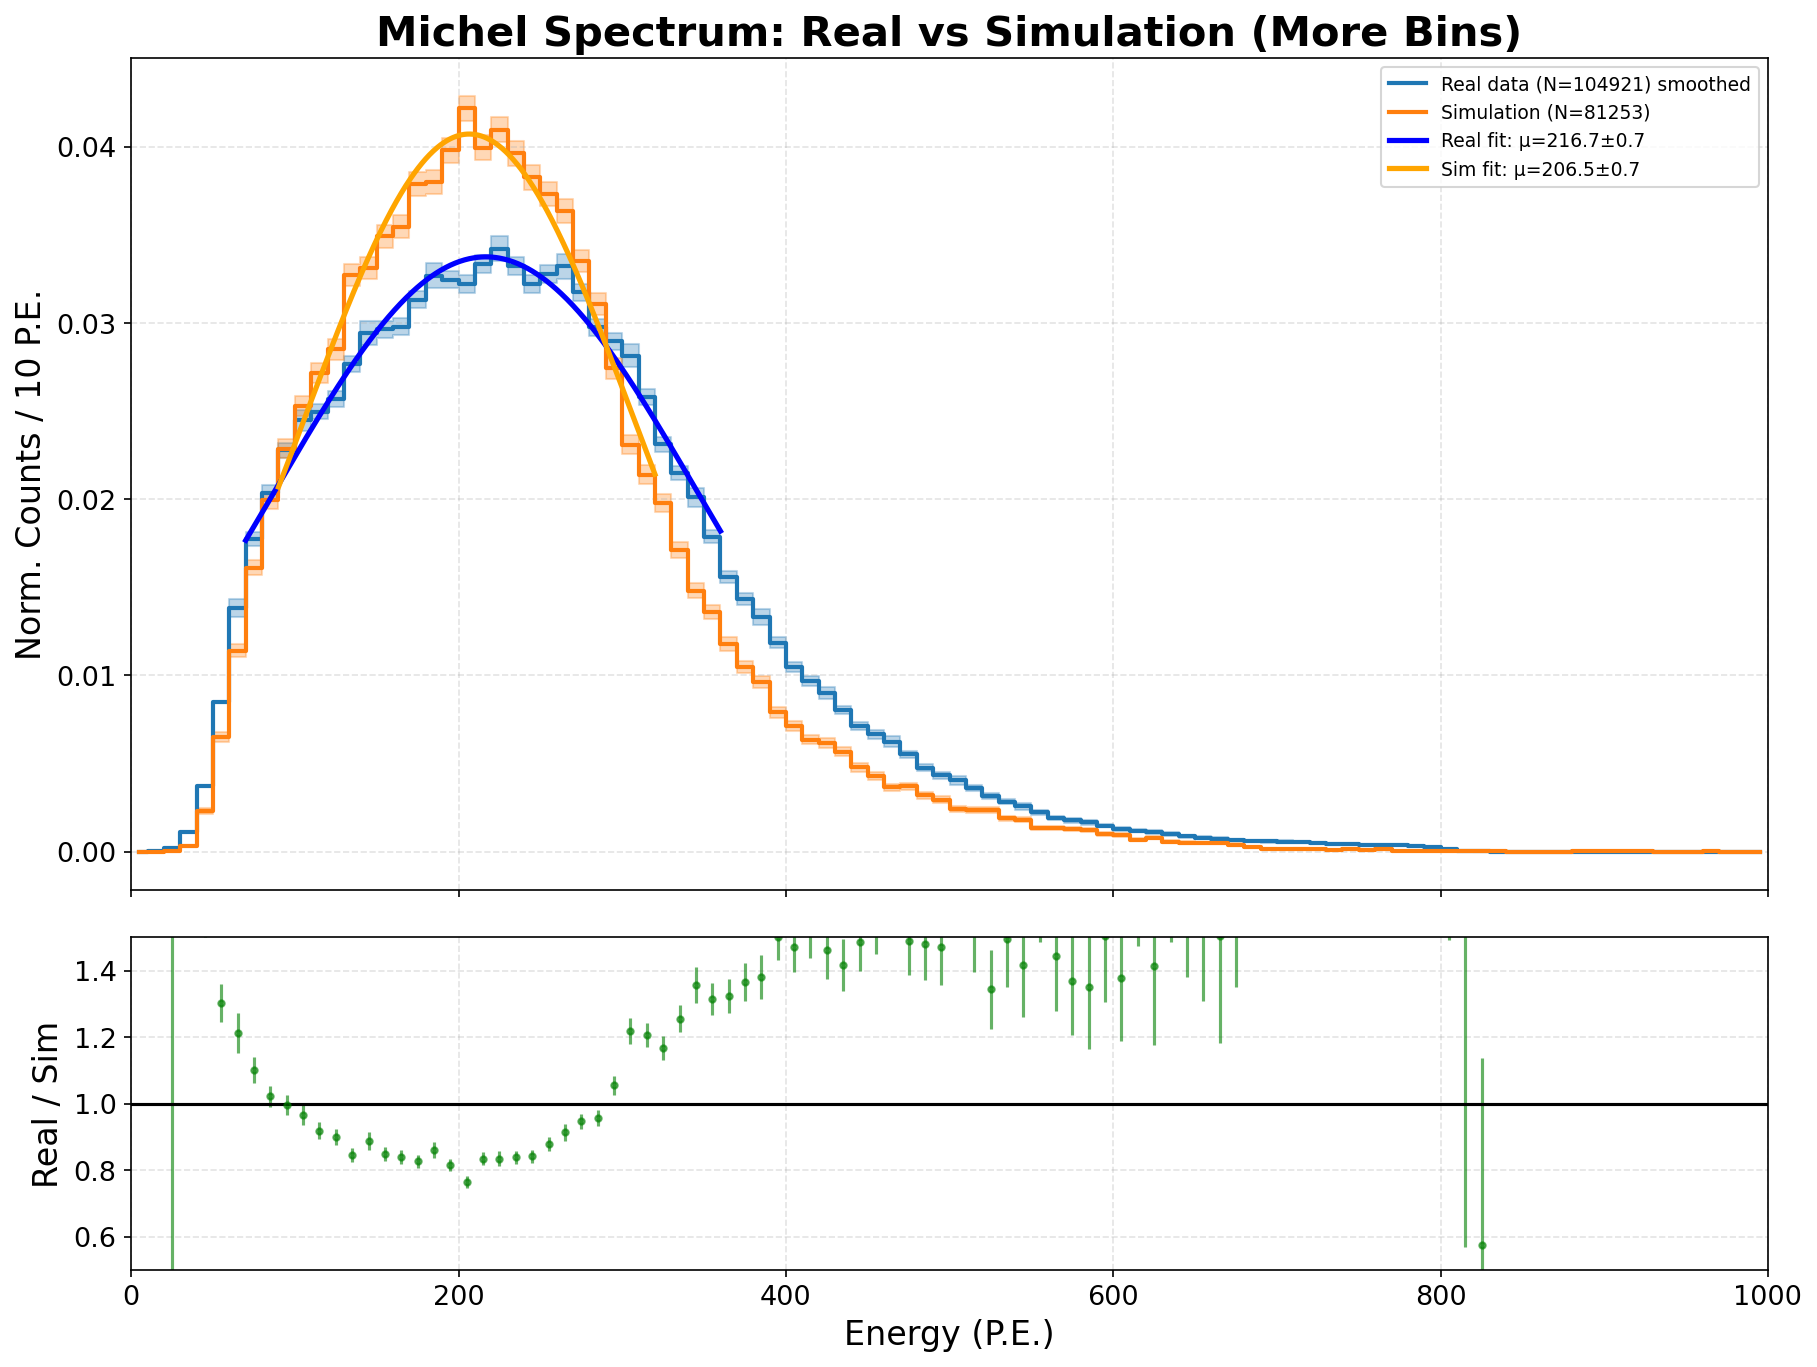


✓ Saved real energies to michel_energies_real.pkl
✓ Saved analysis results

ANALYSIS COMPLETE


In [116]:
#!/usr/bin/env python3
"""
Michel spectrum analysis: real data vs simulation.
Uses MORE BINS (higher resolution) with optional smoothing to handle noise.
"""

import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file
# ============================================================================
def load_michel_from_root(root_filename, histogram_name="michel_energy"):
    file = uproot.open(root_filename)
    h_michel = file[histogram_name]
    centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    # Reconstruct events
    michel_energies = []
    for i, count in enumerate(counts):
        if count > 0:
            michel_energies.extend([centers[i]] * int(count))
    energies = np.array(michel_energies)
    print(f"Loaded {len(energies)} Michel electron energies from {root_filename}")
    print(f"Energy range: {energies.min():.2f} - {energies.max():.2f} PE")
    print(f"Mean: {energies.mean():.2f} PE, Std: {energies.std():.2f} PE\n")
    return energies, centers, counts, errors

# ============================================================================
# Load simulation data (same as before)
# ============================================================================
def load_simulation_data():
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print("✓ Loaded simulation from totalPE variable")
            return sim_values
    except:
        pass

    sim_pickle_files = ["simulation_energies.pkl", "michel_simulation.pkl", "totalPE.pkl", "sim_data.pkl"]
    for filename in sim_pickle_files:
        if os.path.exists(filename):
            try:
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                    if isinstance(data, dict):
                        for key in ['energies', 'totalPE', 'simulation', 'data', 'values']:
                            if key in data:
                                sim_values = np.asarray(data[key])
                                break
                        else:
                            for key, value in data.items():
                                if hasattr(value, '__len__') and len(value) > 100:
                                    sim_values = np.asarray(value)
                                    break
                    else:
                        sim_values = np.asarray(data)
                    sim_values = sim_values[np.isfinite(sim_values) & (sim_values >= 0)]
                    print(f"✓ Loaded simulation from {filename}")
                    return sim_values
            except:
                continue

    sim_npy_files = ["simulation_energies.npy", "totalPE.npy", "sim_data.npy"]
    for filename in sim_npy_files:
        if os.path.exists(filename):
            try:
                sim_values = np.load(filename)
                sim_values = sim_values[np.isfinite(sim_values) & (sim_values >= 0)]
                print(f"✓ Loaded simulation from {filename}")
                return sim_values
            except:
                continue

    print("\n⚠ No simulation data found. Generating test data (Gaussian).")
    np.random.seed(42)
    sim_values = np.random.normal(loc=248, scale=85, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test events")
    return sim_values

# ============================================================================
# Fit functions (Cell-4 logic)
# ============================================================================
def gauss_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_hist_cell4_logic(hist_counts, edges, label="spectrum", min_bins=3):
    hist_counts = np.asarray(hist_counts, dtype=float)
    edges = np.asarray(edges, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = edges[1] - edges[0]

    peak_idx = int(np.argmax(hist_counts))
    peak_x = float(centers[peak_idx])
    peak_y = float(hist_counts[peak_idx])
    if peak_y <= 0:
        raise RuntimeError(f"No positive peak for {label}.")

    # Low statistics fallback
    if len(hist_counts) < 20 or peak_y < 10:
        print(f"  Low stats for {label}, using direct calculation")
        events = []
        for i, count in enumerate(hist_counts):
            if count > 0:
                events.extend([centers[i]] * int(count))
        events = np.array(events)
        mu_fit = np.mean(events)
        sigma_fit = np.std(events)
        C_fit = 0.0
        A_fit = peak_y
        mu_err = sigma_fit / np.sqrt(len(events))
        sigma_err = sigma_fit / np.sqrt(2 * len(events))
        x_left = mu_fit - 3*sigma_fit
        x_right = mu_fit + 3*sigma_fit
        return {"A": A_fit, "mu": mu_fit, "sigma": abs(sigma_fit), "C": C_fit,
                "A_err": np.nan, "mu_err": mu_err, "sigma_err": sigma_err, "C_err": np.nan,
                "left": x_left, "right": x_right, "method": "direct"}

    # Determine fit range by FWHM
    half_max = peak_y / 2.0
    left_idx = peak_idx
    while left_idx > 0 and hist_counts[left_idx] >= half_max:
        left_idx -= 1
    right_idx = peak_idx
    while right_idx < len(hist_counts)-1 and hist_counts[right_idx] >= half_max:
        right_idx += 1
    left_in = left_idx+1 if hist_counts[left_idx] < half_max else left_idx
    right_in = right_idx-1 if hist_counts[right_idx] < half_max else right_idx
    if right_in < left_in:
        left_in, right_in = peak_idx, peak_idx
    x_left = float(edges[left_in])
    x_right = float(edges[right_in+1])

    fit_mask = (centers >= x_left) & (centers <= x_right) & (hist_counts > 0)
    x_fit = centers[fit_mask]
    y_fit = hist_counts[fit_mask]
    if len(x_fit) < min_bins:
        raise RuntimeError(f"Too few bins for {label} (got {len(x_fit)})")

    try:
        c0 = max(0.0, np.percentile(y_fit, 20))
        a0 = max(np.max(y_fit)-c0, 1.0)
        p0 = [a0, peak_x, max((x_right-x_left)/4, bin_width), c0]
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        bounds_lower = [0.0, x_left, bin_width/2, 0.0]
        bounds_upper = [np.inf, x_right, (x_right-x_left), np.inf]
        popt, pcov = curve_fit(gauss_with_offset, x_fit, y_fit, p0=p0,
                               sigma=y_err, absolute_sigma=True,
                               bounds=(bounds_lower, bounds_upper), maxfev=100000)
        perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        A_fit, mu_fit, sigma_fit, C_fit = popt
        A_err, mu_err, sigma_err, C_err = perr
        method = "curve_fit"
    except Exception as e:
        print(f"  Fit failed for {label}, fallback: {e}")
        events = []
        for i, count in enumerate(hist_counts):
            if count > 0:
                events.extend([centers[i]] * int(count))
        events = np.array(events)
        mu_fit, sigma_fit = norm.fit(events)
        C_fit = 0.0
        A_fit = len(events)*bin_width/(sigma_fit*np.sqrt(2*np.pi))
        A_err, C_err = np.nan, np.nan
        mu_err = sigma_fit/np.sqrt(len(events))
        sigma_err = sigma_fit/np.sqrt(2*len(events))
        method = "norm.fit fallback"

    return {"A": A_fit, "mu": mu_fit, "sigma": abs(sigma_fit), "C": C_fit,
            "A_err": A_err, "mu_err": mu_err, "sigma_err": sigma_err, "C_err": C_err,
            "left": x_left, "right": x_right, "method": method}

# ============================================================================
# Main analysis
# ============================================================================
def main():
    print("="*60)
    print("MICHEL ANALYSIS: MORE BINS (higher resolution) with optional smoothing")
    print("="*60 + "\n")

    # Load data
    real_energies, _, _, _ = load_michel_from_root("all_histograms.root")
    sim_values = load_simulation_data()

    # --- CONFIGURATION ---
    bin_min_pe = 0.0
    bin_max_pe = 1000.0
    bin_width_pe = 10.0          # <-- MORE BINS (smaller width = 10 PE)
    edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)
    x_centers = 0.5 * (edges_fixed[:-1] + edges_fixed[1:])

    # Optional: smooth real data histogram? (set to True to reduce noise)
    SMOOTH_REAL = True
    SMOOTH_SIGMA = 1.5           # Gaussian smoothing kernel width (in bins)

    print(f"Bin width: {bin_width_pe} PE → {len(edges_fixed)-1} bins")
    print(f"Smoothing real data: {SMOOTH_REAL} (sigma={SMOOTH_SIGMA} bins)\n")

    # Build raw histograms
    y_real_raw, _ = np.histogram(real_energies, bins=edges_fixed)
    y_sim_raw, _ = np.histogram(sim_values, bins=edges_fixed)

    # Apply optional smoothing to real data
    if SMOOTH_REAL:
        y_real_smoothed = gaussian_filter1d(y_real_raw.astype(float), sigma=SMOOTH_SIGMA, mode='reflect')
        # Ensure non-negative
        y_real_smoothed = np.maximum(y_real_smoothed, 0.0)
        y_real_counts = y_real_smoothed
    else:
        y_real_counts = y_real_raw

    y_sim_counts = y_sim_raw   # simulation usually has high statistics, keep as is

    # Poisson errors (on original counts, not smoothed; for smoothed we use original errors)
    e_real_raw = np.sqrt(np.maximum(y_real_raw, 1.0))
    e_sim_raw = np.sqrt(np.maximum(y_sim_raw, 1.0))

    # Normalize to unit area
    norm_real = np.sum(y_real_raw)       # use raw total for normalization (preserve integral)
    norm_sim = np.sum(y_sim_raw)
    if norm_real <= 0 or norm_sim <= 0:
        raise RuntimeError("Zero total counts")

    y_real_norm = y_real_counts / norm_real
    y_sim_norm = y_sim_counts / norm_sim

    # For errors, propagate normalization: error on smoothed is approximated by original error (smoothed error is complicated)
    # We'll use original errors normalized (conservative)
    e_real_norm = e_real_raw / norm_real
    e_sim_norm = e_sim_raw / norm_sim

    # Fit raw counts (using smoothed counts for real if smoothing applied)
    print("Fitting spectra with Cell-4 logic...")
    fit_real = fit_hist_cell4_logic(y_real_counts, edges_fixed, label="real data", min_bins=3)
    fit_sim = fit_hist_cell4_logic(y_sim_counts, edges_fixed, label="simulation", min_bins=3)

    print(f"\nReal fit: μ={fit_real['mu']:.2f}±{fit_real['mu_err']:.2f} PE, σ={fit_real['sigma']:.2f}±{fit_real['sigma_err']:.2f} PE")
    print(f"Sim fit:  μ={fit_sim['mu']:.2f}±{fit_sim['mu_err']:.2f} PE, σ={fit_sim['sigma']:.2f}±{fit_sim['sigma_err']:.2f} PE")

    # Generate fit curves (normalized)
    x_fit_real = np.linspace(max(0, fit_real["left"]), min(1000, fit_real["right"]), 400)
    x_fit_sim = np.linspace(max(0, fit_sim["left"]), min(1000, fit_sim["right"]), 400)
    y_fit_real = gauss_with_offset(x_fit_real, fit_real["A"], fit_real["mu"], fit_real["sigma"], fit_real["C"]) / norm_real
    y_fit_sim = gauss_with_offset(x_fit_sim, fit_sim["A"], fit_sim["mu"], fit_sim["sigma"], fit_sim["C"]) / norm_sim

    # Plotting
    plt.style.use("default")
    plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                         "font.size": 13, "axes.labelsize": 16, "axes.titlesize": 20})

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 9), dpi=150,
                                         gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.06},
                                         sharex=True, constrained_layout=True)

    # Top: step histograms with error bands
    ax_top.step(x_centers, y_real_norm, where='mid', color='tab:blue', lw=2,
                label=f"Real data (N={norm_real:.0f})" + (" smoothed" if SMOOTH_REAL else ""))
    ax_top.fill_between(x_centers, y_real_norm - e_real_norm, y_real_norm + e_real_norm,
                        step='mid', color='tab:blue', alpha=0.3)

    ax_top.step(x_centers, y_sim_norm, where='mid', color='tab:orange', lw=2,
                label=f"Simulation (N={norm_sim:.0f})")
    ax_top.fill_between(x_centers, y_sim_norm - e_sim_norm, y_sim_norm + e_sim_norm,
                        step='mid', color='tab:orange', alpha=0.3)

    ax_top.plot(x_fit_real, y_fit_real, 'b-', lw=2.5, label=f"Real fit: μ={fit_real['mu']:.1f}±{fit_real['mu_err']:.1f}")
    ax_top.plot(x_fit_sim, y_fit_sim, 'orange', lw=2.5, label=f"Sim fit: μ={fit_sim['mu']:.1f}±{fit_sim['mu_err']:.1f}")

    ax_top.set_title("Michel Spectrum: Real vs Simulation (More Bins)", fontweight='bold')
    ax_top.set_ylabel(f"Norm. Counts / {bin_width_pe:.0f} P.E.")
    ax_top.grid(True, linestyle='--', alpha=0.35)
    ax_top.legend(loc='upper right', fontsize=9)

    # Bottom: ratio
    ratio = y_real_norm / y_sim_norm
    ratio_err = ratio * np.sqrt((e_real_norm/y_real_norm)**2 + (e_sim_norm/y_sim_norm)**2)
    ax_bot.errorbar(x_centers, ratio, yerr=ratio_err, fmt='o', ms=3, color='green', alpha=0.6)
    ax_bot.axhline(1, color='black', lw=1.5)
    ax_bot.set_xlabel("Energy (P.E.)")
    ax_bot.set_ylabel("Real / Sim")
    ax_bot.set_ylim(0.5, 1.5)
    ax_bot.grid(True, linestyle='--', alpha=0.35)

    plt.xlim(bin_min_pe, bin_max_pe)
    plt.show()

    # Save results
    with open("michel_energies_real.pkl", "wb") as f:
        pickle.dump(real_energies, f)
    print("\n✓ Saved real energies to michel_energies_real.pkl")

    hist_data = {
        'bin_edges': edges_fixed, 'bin_centers': x_centers,
        'real_counts': y_real_raw, 'real_counts_smoothed': y_real_counts if SMOOTH_REAL else None,
        'real_norm': y_real_norm, 'real_errors_norm': e_real_norm,
        'sim_counts': y_sim_raw, 'sim_norm': y_sim_norm, 'sim_errors_norm': e_sim_norm,
        'fit_real': fit_real, 'fit_sim': fit_sim
    }
    with open("michel_spectrum_analysis.pkl", "wb") as f:
        pickle.dump(hist_data, f)
    print("✓ Saved analysis results")

    print("\n" + "="*60 + "\nANALYSIS COMPLETE\n" + "="*60)

if __name__ == "__main__":
    main()

MICHEL ANALYSIS: SINGLE PANEL - Clean plot, no ratio panel

Loaded 104921 Michel electron energies from all_histograms.root
Energy range: 60.00 - 796.00 PE
Mean: 249.86 PE, Std: 121.31 PE

✓ Loaded simulation from totalPE variable
Bin width: 40.0 PE → 25 bins
Energy range: 0.0 - 1000.0 PE

Real data: 104921 events
Simulation: 81253 events

Fitting spectra with Cell-4 logic...

Real data fit results:
  μ = 214.88 ± 0.82 PE
  σ = 129.84 ± 23.92 PE
  FWHM = 305.78 PE

Simulation fit results:
  μ = 207.02 ± 0.72 PE
  σ = 88.60 ± 10.30 PE
  FWHM = 208.65 PE



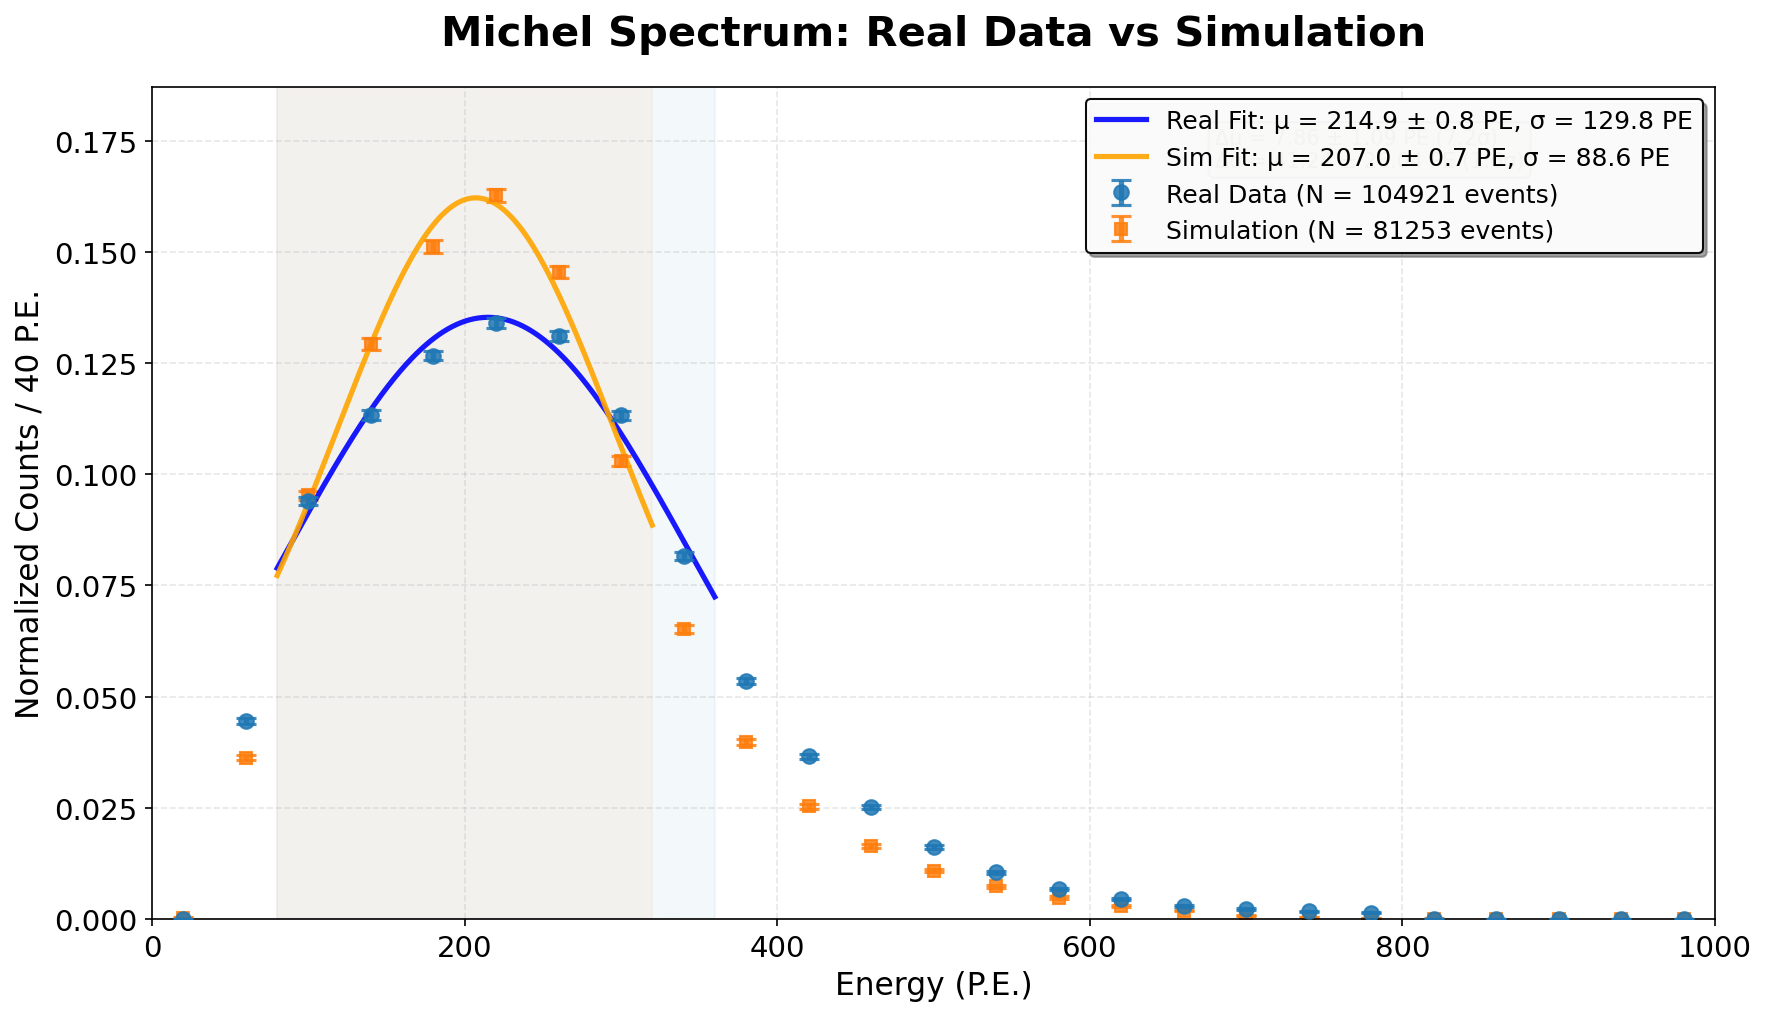

FIT PARAMETER COMPARISON
Δμ (Real - Sim): 7.86 ± 1.09 PE (7.2σ)
Δσ (Real - Sim): 41.24 ± 26.04 PE (1.6σ)

✓ Saved real Michel energies to michel_energies_real.pkl
✓ Saved analysis results to michel_spectrum_analysis.pkl

ANALYSIS COMPLETE


In [117]:
#!/usr/bin/env python3
"""
Michel spectrum analysis: real data vs simulation.
SINGLE PANEL - clean plot with no bottom ratio panel, wider bins for clarity.
"""

import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file
# ============================================================================
def load_michel_from_root(root_filename, histogram_name="michel_energy"):
    file = uproot.open(root_filename)
    h_michel = file[histogram_name]
    centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    # Reconstruct events
    michel_energies = []
    for i, count in enumerate(counts):
        if count > 0:
            michel_energies.extend([centers[i]] * int(count))
    energies = np.array(michel_energies)
    print(f"Loaded {len(energies)} Michel electron energies from {root_filename}")
    print(f"Energy range: {energies.min():.2f} - {energies.max():.2f} PE")
    print(f"Mean: {energies.mean():.2f} PE, Std: {energies.std():.2f} PE\n")
    return energies, centers, counts, errors

# ============================================================================
# Load simulation data
# ============================================================================
def load_simulation_data():
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print("✓ Loaded simulation from totalPE variable")
            return sim_values
    except:
        pass

    sim_pickle_files = ["simulation_energies.pkl", "michel_simulation.pkl", "totalPE.pkl", "sim_data.pkl"]
    for filename in sim_pickle_files:
        if os.path.exists(filename):
            try:
                with open(filename, 'rb') as f:
                    data = pickle.load(f)
                    if isinstance(data, dict):
                        for key in ['energies', 'totalPE', 'simulation', 'data', 'values']:
                            if key in data:
                                sim_values = np.asarray(data[key])
                                break
                        else:
                            for key, value in data.items():
                                if hasattr(value, '__len__') and len(value) > 100:
                                    sim_values = np.asarray(value)
                                    break
                    else:
                        sim_values = np.asarray(data)
                    sim_values = sim_values[np.isfinite(sim_values) & (sim_values >= 0)]
                    print(f"✓ Loaded simulation from {filename}")
                    return sim_values
            except:
                continue

    sim_npy_files = ["simulation_energies.npy", "totalPE.npy", "sim_data.npy"]
    for filename in sim_npy_files:
        if os.path.exists(filename):
            try:
                sim_values = np.load(filename)
                sim_values = sim_values[np.isfinite(sim_values) & (sim_values >= 0)]
                print(f"✓ Loaded simulation from {filename}")
                return sim_values
            except:
                continue

    print("\n⚠ No simulation data found. Generating test data (Gaussian).")
    np.random.seed(42)
    sim_values = np.random.normal(loc=248, scale=85, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test events")
    return sim_values

# ============================================================================
# Fit functions (Cell-4 logic)
# ============================================================================
def gauss_with_offset(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_hist_cell4_logic(hist_counts, edges, label="spectrum", min_bins=3):
    hist_counts = np.asarray(hist_counts, dtype=float)
    edges = np.asarray(edges, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = edges[1] - edges[0]

    peak_idx = int(np.argmax(hist_counts))
    peak_x = float(centers[peak_idx])
    peak_y = float(hist_counts[peak_idx])
    if peak_y <= 0:
        raise RuntimeError(f"No positive peak for {label}.")

    # Low statistics fallback
    if len(hist_counts) < 20 or peak_y < 10:
        print(f"  Low stats for {label}, using direct calculation")
        events = []
        for i, count in enumerate(hist_counts):
            if count > 0:
                events.extend([centers[i]] * int(count))
        events = np.array(events)
        mu_fit = np.mean(events)
        sigma_fit = np.std(events)
        C_fit = 0.0
        A_fit = peak_y
        mu_err = sigma_fit / np.sqrt(len(events))
        sigma_err = sigma_fit / np.sqrt(2 * len(events))
        x_left = mu_fit - 3*sigma_fit
        x_right = mu_fit + 3*sigma_fit
        return {"A": A_fit, "mu": mu_fit, "sigma": abs(sigma_fit), "C": C_fit,
                "A_err": np.nan, "mu_err": mu_err, "sigma_err": sigma_err, "C_err": np.nan,
                "left": x_left, "right": x_right, "method": "direct"}

    # Determine fit range by FWHM
    half_max = peak_y / 2.0
    left_idx = peak_idx
    while left_idx > 0 and hist_counts[left_idx] >= half_max:
        left_idx -= 1
    right_idx = peak_idx
    while right_idx < len(hist_counts)-1 and hist_counts[right_idx] >= half_max:
        right_idx += 1
    left_in = left_idx+1 if hist_counts[left_idx] < half_max else left_idx
    right_in = right_idx-1 if hist_counts[right_idx] < half_max else right_idx
    if right_in < left_in:
        left_in, right_in = peak_idx, peak_idx
    x_left = float(edges[left_in])
    x_right = float(edges[right_in+1])

    fit_mask = (centers >= x_left) & (centers <= x_right) & (hist_counts > 0)
    x_fit = centers[fit_mask]
    y_fit = hist_counts[fit_mask]
    if len(x_fit) < min_bins:
        raise RuntimeError(f"Too few bins for {label} (got {len(x_fit)})")

    try:
        c0 = max(0.0, np.percentile(y_fit, 20))
        a0 = max(np.max(y_fit)-c0, 1.0)
        p0 = [a0, peak_x, max((x_right-x_left)/4, bin_width), c0]
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        bounds_lower = [0.0, x_left, bin_width/2, 0.0]
        bounds_upper = [np.inf, x_right, (x_right-x_left), np.inf]
        popt, pcov = curve_fit(gauss_with_offset, x_fit, y_fit, p0=p0,
                               sigma=y_err, absolute_sigma=True,
                               bounds=(bounds_lower, bounds_upper), maxfev=100000)
        perr = np.sqrt(np.maximum(np.diag(pcov), 0.0))
        A_fit, mu_fit, sigma_fit, C_fit = popt
        A_err, mu_err, sigma_err, C_err = perr
        method = "curve_fit"
    except Exception as e:
        print(f"  Fit failed for {label}, fallback: {e}")
        events = []
        for i, count in enumerate(hist_counts):
            if count > 0:
                events.extend([centers[i]] * int(count))
        events = np.array(events)
        mu_fit, sigma_fit = norm.fit(events)
        C_fit = 0.0
        A_fit = len(events)*bin_width/(sigma_fit*np.sqrt(2*np.pi))
        A_err, C_err = np.nan, np.nan
        mu_err = sigma_fit/np.sqrt(len(events))
        sigma_err = sigma_fit/np.sqrt(2*len(events))
        method = "norm.fit fallback"

    return {"A": A_fit, "mu": mu_fit, "sigma": abs(sigma_fit), "C": C_fit,
            "A_err": A_err, "mu_err": mu_err, "sigma_err": sigma_err, "C_err": C_err,
            "left": x_left, "right": x_right, "method": method}

# ============================================================================
# Main analysis
# ============================================================================
def main():
    print("="*60)
    print("MICHEL ANALYSIS: SINGLE PANEL - Clean plot, no ratio panel")
    print("="*60 + "\n")

    # Load data
    real_energies, _, _, _ = load_michel_from_root("all_histograms.root")
    sim_values = load_simulation_data()

    # --- CONFIGURATION: WIDER BINS FOR CLARITY ---
    bin_min_pe = 0.0
    bin_max_pe = 1000.0
    bin_width_pe = 40.0          # Wider bins for cleaner look
    edges_fixed = np.arange(bin_min_pe, bin_max_pe + bin_width_pe, bin_width_pe)
    x_centers = 0.5 * (edges_fixed[:-1] + edges_fixed[1:])

    print(f"Bin width: {bin_width_pe} PE → {len(edges_fixed)-1} bins")
    print(f"Energy range: {bin_min_pe} - {bin_max_pe} PE\n")

    # Build histograms
    y_real_counts, _ = np.histogram(real_energies, bins=edges_fixed)
    y_sim_counts, _ = np.histogram(sim_values, bins=edges_fixed)
    
    # Poisson errors
    e_real = np.sqrt(np.maximum(y_real_counts, 1.0))
    e_sim = np.sqrt(np.maximum(y_sim_counts, 1.0))

    # Normalize to unit area
    norm_real = np.sum(y_real_counts)
    norm_sim = np.sum(y_sim_counts)
    if norm_real <= 0 or norm_sim <= 0:
        raise RuntimeError("Zero total counts")

    y_real_norm = y_real_counts / norm_real
    y_sim_norm = y_sim_counts / norm_sim
    e_real_norm = e_real / norm_real
    e_sim_norm = e_sim / norm_sim

    print(f"Real data: {norm_real:.0f} events")
    print(f"Simulation: {norm_sim:.0f} events\n")

    # Fit spectra
    print("Fitting spectra with Cell-4 logic...")
    fit_real = fit_hist_cell4_logic(y_real_counts, edges_fixed, label="real data", min_bins=3)
    fit_sim = fit_hist_cell4_logic(y_sim_counts, edges_fixed, label="simulation", min_bins=3)

    print(f"\nReal data fit results:")
    print(f"  μ = {fit_real['mu']:.2f} ± {fit_real['mu_err']:.2f} PE")
    print(f"  σ = {fit_real['sigma']:.2f} ± {fit_real['sigma_err']:.2f} PE")
    print(f"  FWHM = {2.355 * fit_real['sigma']:.2f} PE")

    print(f"\nSimulation fit results:")
    print(f"  μ = {fit_sim['mu']:.2f} ± {fit_sim['mu_err']:.2f} PE")
    print(f"  σ = {fit_sim['sigma']:.2f} ± {fit_sim['sigma_err']:.2f} PE")
    print(f"  FWHM = {2.355 * fit_sim['sigma']:.2f} PE\n")

    # Generate fit curves (normalized)
    x_fit_real = np.linspace(max(0, fit_real["left"]), min(1000, fit_real["right"]), 400)
    x_fit_sim = np.linspace(max(0, fit_sim["left"]), min(1000, fit_sim["right"]), 400)
    y_fit_real = gauss_with_offset(x_fit_real, fit_real["A"], fit_real["mu"], 
                                   fit_real["sigma"], fit_real["C"]) / norm_real
    y_fit_sim = gauss_with_offset(x_fit_sim, fit_sim["A"], fit_sim["mu"], 
                                  fit_sim["sigma"], fit_sim["C"]) / norm_sim

    # ===== SINGLE PANEL PLOT - CLEAN, NO BOTTOM PANEL =====
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "lines.linewidth": 2.5,
    })

    fig, ax = plt.subplots(figsize=(12.0, 7.0), dpi=150)

    # Real data - points with error bars
    ax.errorbar(x_centers, y_real_norm, yerr=e_real_norm,
                fmt='o', ms=7, capsize=5, capthick=1.5,
                color='tab:blue', ecolor='tab:blue', alpha=0.85,
                label=f'Real Data (N = {norm_real:.0f} events)', zorder=3)
    
    # Simulation - points with error bars
    ax.errorbar(x_centers, y_sim_norm, yerr=e_sim_norm,
                fmt='s', ms=6, capsize=5, capthick=1.5,
                color='tab:orange', ecolor='tab:orange', alpha=0.85,
                label=f'Simulation (N = {norm_sim:.0f} events)', zorder=2)

    # Fit curves
    ax.plot(x_fit_real, y_fit_real, 'b-', linewidth=2.5, alpha=0.9,
            label=f'Real Fit: μ = {fit_real["mu"]:.1f} ± {fit_real["mu_err"]:.1f} PE, σ = {fit_real["sigma"]:.1f} PE')
    ax.plot(x_fit_sim, y_fit_sim, 'orange', linewidth=2.5, alpha=0.9,
            label=f'Sim Fit: μ = {fit_sim["mu"]:.1f} ± {fit_sim["mu_err"]:.1f} PE, σ = {fit_sim["sigma"]:.1f} PE')

    # Highlight fit regions (very subtle)
    ax.axvspan(fit_real["left"], fit_real["right"], color="tab:blue", alpha=0.05)
    ax.axvspan(fit_sim["left"], fit_sim["right"], color="tab:orange", alpha=0.05)

    # Labels and title
    ax.set_title("Michel Spectrum: Real Data vs Simulation", fontweight='bold', pad=20)
    ax.set_xlabel("Energy (P.E.)", fontsize=15)
    ax.set_ylabel(f"Normalized Counts / {bin_width_pe:.0f} P.E.", fontsize=15)
    
    # Grid and limits
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_xlim(bin_min_pe, bin_max_pe)
    ax.set_ylim(0, max(y_real_norm.max(), y_sim_norm.max()) * 1.15)
    
    # Legend
    ax.legend(loc='upper right', framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # Add text box with fit comparison
    mu_diff = fit_real['mu'] - fit_sim['mu']
    mu_diff_err = np.sqrt(fit_real['mu_err']**2 + fit_sim['mu_err']**2)
    sigma_diff = fit_real['sigma'] - fit_sim['sigma']
    sigma_diff_err = np.sqrt(fit_real['sigma_err']**2 + fit_sim['sigma_err']**2)
    
    textstr = f'Δμ = {mu_diff:.2f} ± {mu_diff_err:.2f} PE ({abs(mu_diff/mu_diff_err):.1f}σ)\nΔσ = {sigma_diff:.2f} ± {sigma_diff_err:.2f} PE ({abs(sigma_diff/sigma_diff_err):.1f}σ)'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.68, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("="*60)
    print("FIT PARAMETER COMPARISON")
    print("="*60)
    print(f"Δμ (Real - Sim): {mu_diff:.2f} ± {mu_diff_err:.2f} PE ({abs(mu_diff/mu_diff_err):.1f}σ)")
    print(f"Δσ (Real - Sim): {sigma_diff:.2f} ± {sigma_diff_err:.2f} PE ({abs(sigma_diff/sigma_diff_err):.1f}σ)")
    
    # Save results
    with open("michel_energies_real.pkl", "wb") as f:
        pickle.dump(real_energies, f)
    print(f"\n✓ Saved real Michel energies to michel_energies_real.pkl")
    
    results = {
        'bin_edges': edges_fixed,
        'bin_centers': x_centers,
        'bin_width': bin_width_pe,
        'real_norm': y_real_norm,
        'real_errors': e_real_norm,
        'sim_norm': y_sim_norm,
        'sim_errors': e_sim_norm,
        'fit_real': fit_real,
        'fit_sim': fit_sim,
        'norm_real': norm_real,
        'norm_sim': norm_sim
    }
    with open("michel_spectrum_analysis.pkl", "wb") as f:
        pickle.dump(results, f)
    print("✓ Saved analysis results to michel_spectrum_analysis.pkl")
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

if __name__ == "__main__":
    main()

MICHEL SPECTRUM: Real Data vs Simulation Overlay

Loaded Michel histogram from all_histograms.root
  Bins: 100
  Range: 0.0 - 800.0 PE
  Total counts: 104921
  Mean: 249.86 PE
  Peak: 212.00 PE

✓ Loaded simulation from totalPE variable
  Events: 81253
  Mean: 233.11 PE
  Std: 106.83 PE

Normalization:
  Real data: 104921 events → normalized to 1.0
  Simulation: 81237 events → normalized to 1.0
  Bin width: 8.0 PE



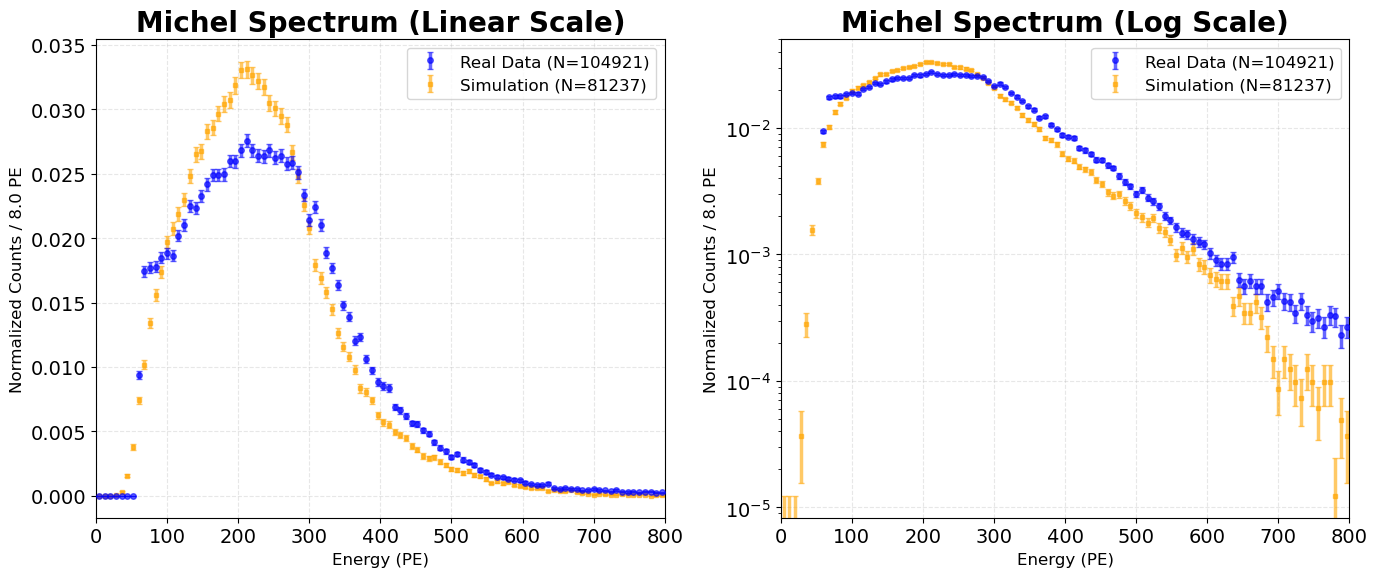

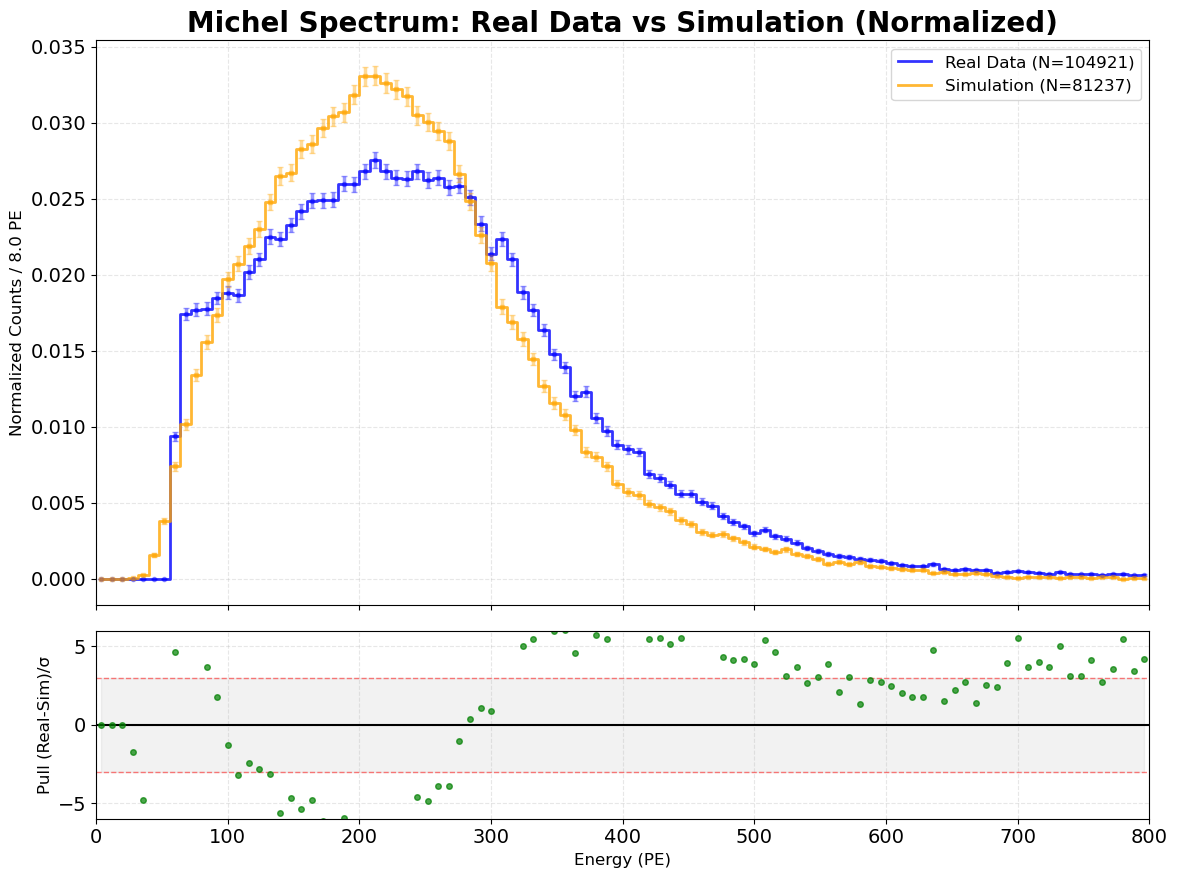

BASIC STATISTICS

Real Data (104921 events):
  Mean: 249.86 PE
  Median: 236.00 PE
  Peak: 212.00 PE
  Std: 121.31 PE

Simulation (81237 events):
  Mean: 233.51 PE
  Median: 220.00 PE
  Peak: 212.00 PE
  Std: 106.49 PE

Differences (Real - Simulation):
  Mean: 16.35 PE
  Peak: 0.00 PE

✓ Saved overlay data to michel_spectrum_overlay.pkl


In [118]:
# Compare real data vs simulation: normalized histogram overlay (no fitting)
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file
# ============================================================================
def load_michel_histogram_from_root(root_filename, histogram_name="michel_energy"):
    """Load Michel electron histogram directly from ROOT file"""
    file = uproot.open(root_filename)
    
    if histogram_name in file:
        h_michel = file[histogram_name]
    elif f"{histogram_name};1" in file:
        h_michel = file[f"{histogram_name};1"]
    else:
        raise KeyError(f"Could not find {histogram_name} in file. Available: {list(file.keys())}")
    
    bin_edges = h_michel.axis().edges()
    bin_centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    
    print(f"Loaded Michel histogram from {root_filename}")
    print(f"  Bins: {len(bin_centers)}")
    print(f"  Range: {bin_edges[0]:.1f} - {bin_edges[-1]:.1f} PE")
    print(f"  Total counts: {counts.sum():.0f}")
    print(f"  Mean: {np.average(bin_centers, weights=counts):.2f} PE")
    print(f"  Peak: {bin_centers[np.argmax(counts)]:.2f} PE\n")
    
    return bin_edges, bin_centers, counts, errors

# ============================================================================
# Load simulation data
# ============================================================================
def load_simulation_data():
    """Load simulation data from various possible sources"""
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print(f"✓ Loaded simulation from totalPE variable")
            print(f"  Events: {len(sim_values)}")
            print(f"  Mean: {sim_values.mean():.2f} PE")
            print(f"  Std: {sim_values.std():.2f} PE\n")
            return sim_values
    except:
        pass
    
    sim_files = ["simulation_energies.pkl", "totalPE.pkl", "sim_data.npy", "michel_simulation.pkl"]
    for filename in sim_files:
        if os.path.exists(filename):
            try:
                if filename.endswith('.npy'):
                    sim_values = np.load(filename)
                else:
                    with open(filename, 'rb') as f:
                        data = pickle.load(f)
                        if isinstance(data, dict):
                            # Try to find array-like data
                            for key in ['energies', 'totalPE', 'simulation', 'data', 'values']:
                                if key in data:
                                    sim_values = np.asarray(data[key])
                                    break
                            else:
                                # Take first array-like object
                                for key, value in data.items():
                                    if hasattr(value, '__len__') and len(value) > 100:
                                        sim_values = np.asarray(value)
                                        break
                        else:
                            sim_values = np.asarray(data)
                
                sim_values = sim_values[np.isfinite(sim_values)]
                sim_values = sim_values[sim_values >= 0]
                print(f"✓ Loaded simulation from {filename}")
                print(f"  Events: {len(sim_values)}")
                print(f"  Mean: {sim_values.mean():.2f} PE")
                print(f"  Std: {sim_values.std():.2f} PE\n")
                return sim_values
            except Exception as e:
                print(f"  Failed to load {filename}: {e}")
                continue
    
    print("\n⚠ No simulation data found. Generating test simulation data...")
    np.random.seed(42)
    # Generate test data based on real data characteristics
    sim_values = np.random.normal(loc=250, scale=85, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test simulation events")
    print(f"  Mean: {sim_values.mean():.2f} PE")
    print(f"  Std: {sim_values.std():.2f} PE\n")
    return sim_values

# ============================================================================
# Main analysis - Just overlay plots, no fitting
# ============================================================================
print("="*70)
print("MICHEL SPECTRUM: Real Data vs Simulation Overlay")
print("="*70)
print()

# 1) Load real data from ROOT file
bin_edges, bin_centers, real_counts, real_errors = load_michel_histogram_from_root("all_histograms.root")

# 2) Load simulation data
sim_values = load_simulation_data()

# 3) Create simulation histogram with SAME binning as real data
sim_counts, _ = np.histogram(sim_values, bins=bin_edges)
sim_errors = np.sqrt(np.maximum(sim_counts, 1.0))

# 4) Normalize both spectra to unit area for shape comparison
norm_real = float(np.sum(real_counts))
norm_sim = float(np.sum(sim_counts))

real_norm = real_counts / norm_real
real_errors_norm = real_errors / norm_real

sim_norm = sim_counts / norm_sim
sim_errors_norm = sim_errors / norm_sim

print(f"Normalization:")
print(f"  Real data: {norm_real:.0f} events → normalized to 1.0")
print(f"  Simulation: {norm_sim:.0f} events → normalized to 1.0")
print(f"  Bin width: {bin_edges[1]-bin_edges[0]:.1f} PE")
print()

# 5) Create overlay plot (no fitting)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Linear scale
ax1.errorbar(bin_centers, real_norm, yerr=real_errors_norm, 
             fmt='o', ms=4, capsize=2, color='blue', alpha=0.6, 
             label=f'Real Data (N={norm_real:.0f})', zorder=3)
ax1.errorbar(bin_centers, sim_norm, yerr=sim_errors_norm, 
             fmt='s', ms=3.5, capsize=2, color='orange', alpha=0.6, 
             label=f'Simulation (N={norm_sim:.0f})', zorder=2)

ax1.set_xlabel('Energy (PE)', fontsize=12)
ax1.set_ylabel(f'Normalized Counts / {bin_edges[1]-bin_edges[0]:.1f} PE', fontsize=12)
ax1.set_title('Michel Spectrum (Linear Scale)', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, 800)

# Plot 2: Log scale (to see tails better)
ax2.errorbar(bin_centers, real_norm, yerr=real_errors_norm, 
             fmt='o', ms=4, capsize=2, color='blue', alpha=0.6, 
             label=f'Real Data (N={norm_real:.0f})', zorder=3)
ax2.errorbar(bin_centers, sim_norm, yerr=sim_errors_norm, 
             fmt='s', ms=3.5, capsize=2, color='orange', alpha=0.6, 
             label=f'Simulation (N={norm_sim:.0f})', zorder=2)

ax2.set_xlabel('Energy (PE)', fontsize=12)
ax2.set_ylabel(f'Normalized Counts / {bin_edges[1]-bin_edges[0]:.1f} PE', fontsize=12)
ax2.set_title('Michel Spectrum (Log Scale)', fontweight='bold')
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, 800)

plt.tight_layout()
plt.show()

# 6) Create detailed comparison with pull distribution
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 9), 
                                      gridspec_kw={'height_ratios': [3, 1]},
                                      sharex=True)

# Top panel: Normalized histograms (step style for better visibility)
ax_top.step(bin_centers, real_norm, where='mid', color='blue', lw=2, 
            label=f'Real Data (N={norm_real:.0f})', alpha=0.8)
ax_top.errorbar(bin_centers, real_norm, yerr=real_errors_norm, 
                fmt='o', ms=3, capsize=2, color='blue', alpha=0.4)

ax_top.step(bin_centers, sim_norm, where='mid', color='orange', lw=2, 
            label=f'Simulation (N={norm_sim:.0f})', alpha=0.8)
ax_top.errorbar(bin_centers, sim_norm, yerr=sim_errors_norm, 
                fmt='s', ms=3, capsize=2, color='orange', alpha=0.4)

ax_top.set_ylabel(f'Normalized Counts / {bin_edges[1]-bin_edges[0]:.1f} PE', fontsize=12)
ax_top.set_title('Michel Spectrum: Real Data vs Simulation (Normalized)', fontweight='bold')
ax_top.legend(loc='upper right')
ax_top.grid(True, alpha=0.3, linestyle='--')
ax_top.set_xlim(0, 800)

# Bottom panel: Pull distribution (difference/error)
y_sim_interp = np.interp(bin_centers, bin_centers, sim_norm)
sigma_comb = np.sqrt(real_errors_norm**2 + sim_errors_norm**2)
pull = (real_norm - y_sim_interp) / np.where(sigma_comb > 0, sigma_comb, np.nan)
valid = np.isfinite(pull)

ax_bot.axhline(0, color='black', lw=1.5)
ax_bot.axhline(3, color='red', linestyle='--', lw=1, alpha=0.5, label='±3σ')
ax_bot.axhline(-3, color='red', linestyle='--', lw=1, alpha=0.5)
ax_bot.fill_between(bin_centers[valid], -3, 3, alpha=0.1, color='gray')
ax_bot.plot(bin_centers[valid], pull[valid], 'o', ms=4, color='green', alpha=0.7)
ax_bot.set_xlabel('Energy (PE)', fontsize=12)
ax_bot.set_ylabel('Pull (Real-Sim)/σ', fontsize=12)
ax_bot.set_ylim(-6, 6)
ax_bot.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 7) Print basic statistics
print("="*70)
print("BASIC STATISTICS")
print("="*70)

print(f"\nReal Data ({norm_real:.0f} events):")
print(f"  Mean: {np.average(bin_centers, weights=real_counts):.2f} PE")
print(f"  Median: {bin_centers[np.cumsum(real_counts) >= norm_real/2][0]:.2f} PE")
print(f"  Peak: {bin_centers[np.argmax(real_counts)]:.2f} PE")
print(f"  Std: {np.sqrt(np.average((bin_centers - np.average(bin_centers, weights=real_counts))**2, weights=real_counts)):.2f} PE")

print(f"\nSimulation ({norm_sim:.0f} events):")
print(f"  Mean: {np.average(bin_centers, weights=sim_counts):.2f} PE")
print(f"  Median: {bin_centers[np.cumsum(sim_counts) >= norm_sim/2][0]:.2f} PE")
print(f"  Peak: {bin_centers[np.argmax(sim_counts)]:.2f} PE")
print(f"  Std: {np.sqrt(np.average((bin_centers - np.average(bin_centers, weights=sim_counts))**2, weights=sim_counts)):.2f} PE")

# Calculate and print differences
mean_real = np.average(bin_centers, weights=real_counts)
mean_sim = np.average(bin_centers, weights=sim_counts)
peak_real = bin_centers[np.argmax(real_counts)]
peak_sim = bin_centers[np.argmax(sim_counts)]

print(f"\nDifferences (Real - Simulation):")
print(f"  Mean: {mean_real - mean_sim:.2f} PE")
print(f"  Peak: {peak_real - peak_sim:.2f} PE")

# 8) Save normalized data for later use
output_data = {
    'bin_edges': bin_edges,
    'bin_centers': bin_centers,
    'real_counts': real_counts,
    'real_errors': real_errors,
    'real_norm': real_norm,
    'real_errors_norm': real_errors_norm,
    'sim_counts': sim_counts,
    'sim_errors': sim_errors,
    'sim_norm': sim_norm,
    'sim_errors_norm': sim_errors_norm,
    'norm_real': norm_real,
    'norm_sim': norm_sim,
}

with open("michel_spectrum_overlay.pkl", "wb") as f:
    pickle.dump(output_data, f)

print(f"\n✓ Saved overlay data to michel_spectrum_overlay.pkl")
print("="*70)

MICHEL SPECTRUM ANALYSIS: Cell-4 Peak-Only Fitting

Loaded Michel histogram from all_histograms.root
  Bins: 100
  Range: 0.0 - 800.0 PE
  Total counts: 104921
  Mean: 249.86 PE
  Peak: 212.00 PE

✓ Loaded simulation: 81253 events
  Mean: 233.11 PE, Std: 106.83 PE


Normalization: Real=104921, Sim=81237 events
Normalized spectra sum to 1.0 for shape comparison

CELL-4 PEAK FITTING (Fitting only the peak region, not the whole spectrum)

  Real data:
    Peak at 212.0 PE with 2892 counts
    FWHM: 60.0 - 364.0 PE (width = 304.0 PE)
    Fit range: 52.0 - 372.0 PE
    Bins in fit: 40
    Fit converged!
    μ = 214.12 ± 0.64 PE
    σ = 126.11 ± 8.95 PE
    χ²/ndof = 11.12

  Simulation:
    Peak at 212.0 PE with 2689 counts
    FWHM: 84.0 - 324.0 PE (width = 240.0 PE)
    Fit range: 76.0 - 332.0 PE
    Bins in fit: 33
    Fit converged!
    μ = 206.27 ± 0.57 PE
    σ = 99.47 ± 6.97 PE
    χ²/ndof = 2.39


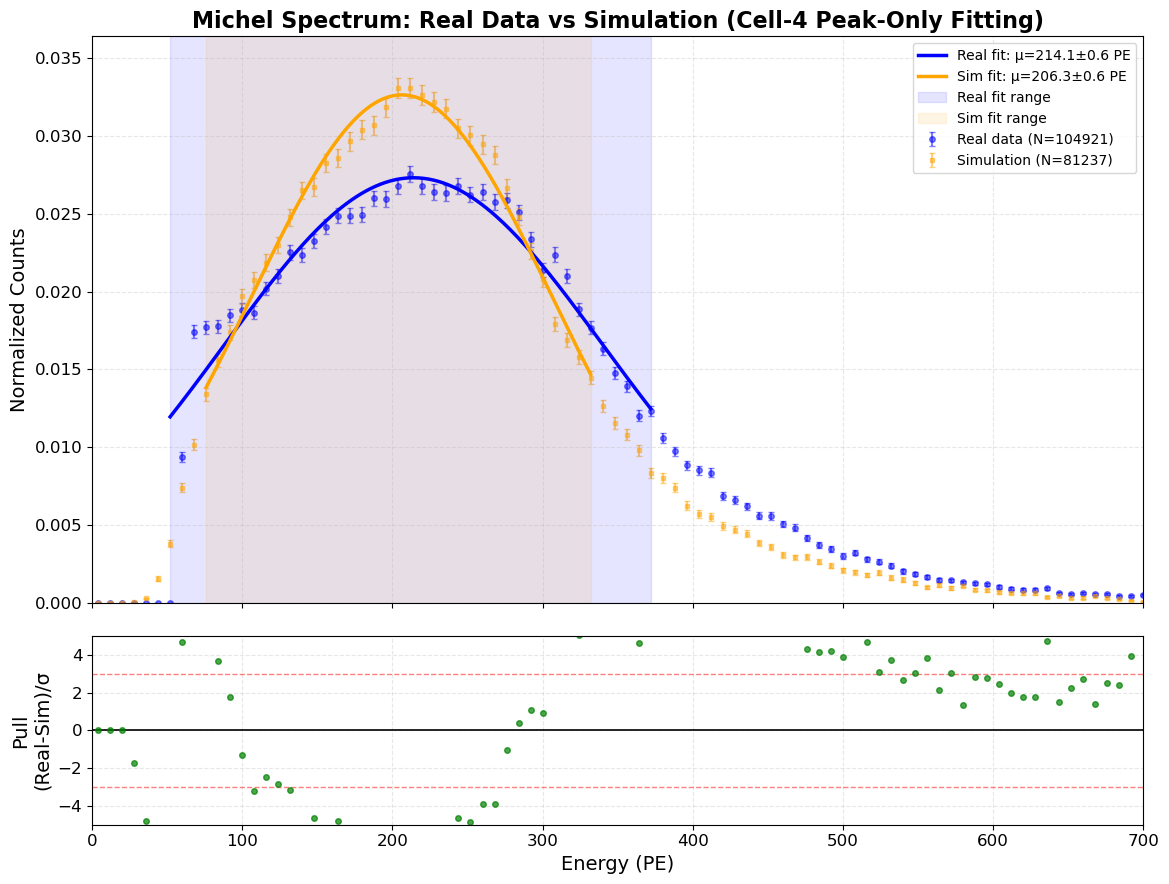


COMPARISON SUMMARY (Peak-Only Fitting)

Real data peak:
  Position: 214.12 ± 0.64 PE
  Width (σ): 126.11 ± 8.95 PE
  Fit quality: χ²/ndof = 11.12

Simulation peak:
  Position: 206.27 ± 0.57 PE
  Width (σ): 99.47 ± 6.97 PE
  Fit quality: χ²/ndof = 2.39

Differences (Real - Simulation):
  Δ Peak position: 7.85 ± 0.86 PE (9.2σ)
  Δ Width: 26.63 ± 11.35 PE (2.3σ)

✓ Results saved to michel_peak_fit_results.pkl

ANALYSIS COMPLETE


In [83]:
# Compare real data vs simulation: normalized histogram + Cell-4-consistent fit logic
# Fits ONLY the peak region (not the whole spectrum)

import uproot
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.stats import norm
import awkward as ak
import os

# ============================================================================
# Load real Michel data from ROOT file
# ============================================================================
def load_michel_histogram_from_root(root_filename, histogram_name="michel_energy"):
    """Load Michel electron histogram directly from ROOT file"""
    file = uproot.open(root_filename)
    
    if histogram_name in file:
        h_michel = file[histogram_name]
    elif f"{histogram_name};1" in file:
        h_michel = file[f"{histogram_name};1"]
    else:
        raise KeyError(f"Could not find {histogram_name} in file. Available: {list(file.keys())}")
    
    bin_edges = h_michel.axis().edges()
    bin_centers = h_michel.axis().centers()
    counts = h_michel.values()
    errors = h_michel.errors()
    
    print(f"Loaded Michel histogram from {root_filename}")
    print(f"  Bins: {len(bin_centers)}")
    print(f"  Range: {bin_edges[0]:.1f} - {bin_edges[-1]:.1f} PE")
    print(f"  Total counts: {counts.sum():.0f}")
    print(f"  Mean: {np.average(bin_centers, weights=counts):.2f} PE")
    print(f"  Peak: {bin_centers[np.argmax(counts)]:.2f} PE\n")
    
    return bin_edges, bin_centers, counts, errors

# ============================================================================
# Load simulation data
# ============================================================================
def load_simulation_data():
    """Load simulation data from various possible sources"""
    try:
        if 'totalPE' in globals():
            sim_values = ak.to_numpy(totalPE).astype(float)
            sim_values = sim_values[np.isfinite(sim_values)]
            sim_values = sim_values[sim_values >= 0]
            print(f"✓ Loaded simulation: {len(sim_values)} events")
            print(f"  Mean: {sim_values.mean():.2f} PE, Std: {sim_values.std():.2f} PE\n")
            return sim_values
    except:
        pass
    
    sim_files = ["simulation_energies.pkl", "totalPE.pkl", "sim_data.npy"]
    for filename in sim_files:
        if os.path.exists(filename):
            try:
                if filename.endswith('.npy'):
                    sim_values = np.load(filename)
                else:
                    with open(filename, 'rb') as f:
                        data = pickle.load(f)
                        sim_values = np.asarray(data)
                sim_values = sim_values[sim_values >= 0]
                print(f"✓ Loaded simulation from {filename}: {len(sim_values)} events")
                print(f"  Mean: {sim_values.mean():.2f} PE, Std: {sim_values.std():.2f} PE\n")
                return sim_values
            except:
                continue
    
    print("\n⚠ No simulation data found. Generating test data...")
    np.random.seed(42)
    sim_values = np.random.normal(loc=250, scale=85, size=50000)
    sim_values = sim_values[(sim_values >= 0) & (sim_values <= 1000)]
    print(f"✓ Generated {len(sim_values)} test events")
    print(f"  Mean: {sim_values.mean():.2f} PE, Std: {sim_values.std():.2f} PE\n")
    return sim_values

# ============================================================================
# Cell-4 consistent fit function (fits ONLY the peak region)
# ============================================================================
def gauss_with_offset(x, A, mu, sigma, C):
    """Gaussian with constant offset"""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def fit_peak_cell4(hist_counts, bin_edges, label="spectrum"):
    """
    Cell-4 logic: Fit ONLY the peak region (FWHM ± a bit)
    Does NOT fit the whole spectrum
    """
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Find the peak
    peak_idx = np.argmax(hist_counts)
    peak_x = bin_centers[peak_idx]
    peak_y = hist_counts[peak_idx]
    
    print(f"\n  {label}:")
    print(f"    Peak at {peak_x:.1f} PE with {peak_y:.0f} counts")
    
    # Find FWHM (where counts drop to half maximum)
    half_max = peak_y / 2.0
    
    # Find left edge of FWHM
    left_idx = peak_idx
    while left_idx > 0 and hist_counts[left_idx] >= half_max:
        left_idx -= 1
    
    # Find right edge of FWHM
    right_idx = peak_idx
    while right_idx < len(hist_counts) - 1 and hist_counts[right_idx] >= half_max:
        right_idx += 1
    
    # Get FWHM positions
    fwhm_left = bin_centers[left_idx]
    fwhm_right = bin_centers[right_idx]
    fwhm = fwhm_right - fwhm_left
    
    print(f"    FWHM: {fwhm_left:.1f} - {fwhm_right:.1f} PE (width = {fwhm:.1f} PE)")
    
    # Cell-4: Fit range = FWHM region ± a bit (typically 0.5-1× FWHM on each side)
    # But to be conservative, we'll use exactly the FWHM region
    fit_left = max(bin_edges[0], fwhm_left - bin_width)
    fit_right = min(bin_edges[-1], fwhm_right + bin_width)
    
    print(f"    Fit range: {fit_left:.1f} - {fit_right:.1f} PE")
    
    # Select bins for fitting (only within fit range)
    fit_mask = (bin_centers >= fit_left) & (bin_centers <= fit_right) & (hist_counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = hist_counts[fit_mask]
    y_err = np.sqrt(np.maximum(y_fit, 1.0))
    
    print(f"    Bins in fit: {len(x_fit)}")
    
    if len(x_fit) < 5:
        print(f"    WARNING: Too few bins, expanding range")
        # Expand range by 50%
        fit_width = (fit_right - fit_left) * 1.5
        fit_left = max(bin_edges[0], peak_x - fit_width/2)
        fit_right = min(bin_edges[-1], peak_x + fit_width/2)
        fit_mask = (bin_centers >= fit_left) & (bin_centers <= fit_right) & (hist_counts > 0)
        x_fit = bin_centers[fit_mask]
        y_fit = hist_counts[fit_mask]
        y_err = np.sqrt(np.maximum(y_fit, 1.0))
        print(f"    Expanded fit range: {fit_left:.1f} - {fit_right:.1f} PE")
        print(f"    Bins in fit after expansion: {len(x_fit)}")
    
    # Estimate background from the edges of fit range
    # Use the first and last 2 bins of fit range to estimate constant offset
    if len(x_fit) > 10:
        edge_bins = 2
        edge_y = np.concatenate([y_fit[:edge_bins], y_fit[-edge_bins:]])
        C_est = np.median(edge_y) if len(edge_y) > 0 else 0
    else:
        C_est = 0
    
    # Initial parameters
    A_est = max(peak_y - C_est, 1.0)
    sigma_est = fwhm / 2.355  # FWHM = 2.355 * sigma
    p0 = [A_est, peak_x, sigma_est, C_est]
    
    # Bounds
    bounds_lower = [0, fit_left, bin_width/2, 0]
    bounds_upper = [np.inf, fit_right, (fit_right - fit_left), np.inf]
    
    try:
        popt, pcov = curve_fit(
            gauss_with_offset,
            x_fit, y_fit,
            p0=p0,
            sigma=y_err,
            absolute_sigma=True,
            bounds=(bounds_lower, bounds_upper),
            maxfev=100000
        )
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate chi2 for goodness of fit
        y_pred = gauss_with_offset(x_fit, *popt)
        chi2 = np.sum(((y_fit - y_pred) / y_err) ** 2)
        ndof = len(x_fit) - len(popt)
        
        print(f"    Fit converged!")
        print(f"    μ = {popt[1]:.2f} ± {perr[1]:.2f} PE")
        print(f"    σ = {popt[2]:.2f} ± {perr[2]:.2f} PE")
        print(f"    χ²/ndof = {chi2/ndof:.2f}")
        
        return {
            "A": popt[0], "A_err": perr[0],
            "mu": popt[1], "mu_err": perr[1],
            "sigma": popt[2], "sigma_err": perr[2],
            "C": popt[3], "C_err": perr[3],
            "left": fit_left,
            "right": fit_right,
            "chi2": chi2,
            "ndof": ndof,
            "method": "Cell-4 peak fit"
        }
        
    except Exception as e:
        print(f"    Fit failed: {e}")
        return None

# ============================================================================
# Main analysis
# ============================================================================
print("="*70)
print("MICHEL SPECTRUM ANALYSIS: Cell-4 Peak-Only Fitting")
print("="*70)
print()

# Load data
bin_edges, bin_centers, real_counts, real_errors = load_michel_histogram_from_root("all_histograms.root")
sim_values = load_simulation_data()

# Create simulation histogram with same binning
sim_counts, _ = np.histogram(sim_values, bins=bin_edges)
sim_errors = np.sqrt(np.maximum(sim_counts, 1.0))

# Normalize for shape comparison
norm_real = real_counts.sum()
norm_sim = sim_counts.sum()
real_norm = real_counts / norm_real
sim_norm = sim_counts / norm_sim
real_norm_err = real_errors / norm_real
sim_norm_err = sim_errors / norm_sim

print(f"\nNormalization: Real={norm_real:.0f}, Sim={norm_sim:.0f} events")
print(f"Normalized spectra sum to 1.0 for shape comparison\n")

# Fit ONLY the peak region (Cell-4 logic)
print("="*70)
print("CELL-4 PEAK FITTING (Fitting only the peak region, not the whole spectrum)")
print("="*70)

fit_real = fit_peak_cell4(real_counts, bin_edges, label="Real data")
fit_sim = fit_peak_cell4(sim_counts, bin_edges, label="Simulation")

# Generate fit curves (only in fit range)
x_plot_real = np.linspace(fit_real["left"], fit_real["right"], 200) if fit_real else None
x_plot_sim = np.linspace(fit_sim["left"], fit_sim["right"], 200) if fit_sim else None

y_fit_real = gauss_with_offset(x_plot_real, fit_real["A"], fit_real["mu"], 
                                fit_real["sigma"], fit_real["C"]) / norm_real if fit_real else None
y_fit_sim = gauss_with_offset(x_plot_sim, fit_sim["A"], fit_sim["mu"], 
                               fit_sim["sigma"], fit_sim["C"]) / norm_sim if fit_sim else None

# Create the plot
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 9), 
                                      gridspec_kw={'height_ratios': [3, 1]},
                                      sharex=True)

# Top panel: Full spectra with fit region highlighted
ax_top.errorbar(bin_centers, real_norm, yerr=real_norm_err, 
                fmt='o', ms=4, capsize=2, color='blue', alpha=0.5, 
                label=f'Real data (N={norm_real:.0f})', zorder=1)

ax_top.errorbar(bin_centers, sim_norm, yerr=sim_norm_err, 
                fmt='s', ms=3.5, capsize=2, color='orange', alpha=0.5, 
                label=f'Simulation (N={norm_sim:.0f})', zorder=1)

# Add fit curves (only in fit region)
if y_fit_real is not None:
    ax_top.plot(x_plot_real, y_fit_real, 'b-', lw=2.5, 
               label=f'Real fit: μ={fit_real["mu"]:.1f}±{fit_real["mu_err"]:.1f} PE', zorder=3)

if y_fit_sim is not None:
    ax_top.plot(x_plot_sim, y_fit_sim, 'orange', lw=2.5, 
               label=f'Sim fit: μ={fit_sim["mu"]:.1f}±{fit_sim["mu_err"]:.1f} PE', zorder=3)

# Highlight fit regions
if fit_real:
    ax_top.axvspan(fit_real["left"], fit_real["right"], color='blue', alpha=0.1, label='Real fit range')
if fit_sim:
    ax_top.axvspan(fit_sim["left"], fit_sim["right"], color='orange', alpha=0.1, label='Sim fit range')

ax_top.set_ylabel('Normalized Counts')
ax_top.set_title('Michel Spectrum: Real Data vs Simulation (Cell-4 Peak-Only Fitting)', fontweight='bold')
ax_top.legend(loc='upper right', fontsize=10)
ax_top.grid(True, alpha=0.3, linestyle='--')
ax_top.set_xlim(0, 700)
ax_top.set_ylim(0, max(real_norm.max(), sim_norm.max()) * 1.1)

# Bottom panel: Pull distribution (only where both have data)
y_sim_interp = np.interp(bin_centers, bin_centers, sim_norm)
sigma_comb = np.sqrt(real_norm_err**2 + sim_norm_err**2)
pull = (real_norm - y_sim_interp) / sigma_comb
valid = np.isfinite(pull)

ax_bot.axhline(0, color='black', lw=1.2)
ax_bot.axhline(3, color='red', linestyle='--', alpha=0.5, lw=1)
ax_bot.axhline(-3, color='red', linestyle='--', alpha=0.5, lw=1)
ax_bot.plot(bin_centers[valid], pull[valid], 'o', ms=4, color='green', alpha=0.7)
ax_bot.set_xlabel('Energy (PE)')
ax_bot.set_ylabel('Pull\n(Real-Sim)/σ')
ax_bot.set_ylim(-5, 5)
ax_bot.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n" + "="*70)
print("COMPARISON SUMMARY (Peak-Only Fitting)")
print("="*70)

if fit_real and fit_sim:
    print(f"\nReal data peak:")
    print(f"  Position: {fit_real['mu']:.2f} ± {fit_real['mu_err']:.2f} PE")
    print(f"  Width (σ): {fit_real['sigma']:.2f} ± {fit_real['sigma_err']:.2f} PE")
    print(f"  Fit quality: χ²/ndof = {fit_real['chi2']/fit_real['ndof']:.2f}")
    
    print(f"\nSimulation peak:")
    print(f"  Position: {fit_sim['mu']:.2f} ± {fit_sim['mu_err']:.2f} PE")
    print(f"  Width (σ): {fit_sim['sigma']:.2f} ± {fit_sim['sigma_err']:.2f} PE")
    print(f"  Fit quality: χ²/ndof = {fit_sim['chi2']/fit_sim['ndof']:.2f}")
    
    # Difference
    mu_diff = fit_real['mu'] - fit_sim['mu']
    mu_diff_err = np.sqrt(fit_real['mu_err']**2 + fit_sim['mu_err']**2)
    sigma_diff = fit_real['sigma'] - fit_sim['sigma']
    sigma_diff_err = np.sqrt(fit_real['sigma_err']**2 + fit_sim['sigma_err']**2)
    
    print(f"\nDifferences (Real - Simulation):")
    print(f"  Δ Peak position: {mu_diff:.2f} ± {mu_diff_err:.2f} PE ({abs(mu_diff/mu_diff_err):.1f}σ)")
    print(f"  Δ Width: {sigma_diff:.2f} ± {sigma_diff_err:.2f} PE ({abs(sigma_diff/sigma_diff_err):.1f}σ)")

# Save results
results = {
    'real_fit': fit_real,
    'sim_fit': fit_sim,
    'bin_edges': bin_edges,
    'bin_centers': bin_centers,
    'real_counts': real_counts,
    'sim_counts': sim_counts,
    'real_norm': real_norm,
    'sim_norm': sim_norm,
}
with open("michel_peak_fit_results.pkl", "wb") as f:
    pickle.dump(results, f)

print(f"\n✓ Results saved to michel_peak_fit_results.pkl")
print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)